# RANGKUMAN KOMPREHENSIF — Deep EDA Data Klaim Asuransi

---

## Executive Summary

Notebook ini merupakan **rangkuman mendalam** dari analisis eksplorasi data (Deep EDA) terhadap data klaim asuransi kesehatan. Analisis mencakup **4.625 transaksi klaim** dari **1.210 polis aktif** (dari total 4.096 polis), dengan **total nominal klaim Rp 254,6 Miliar** selama periode **Januari 2024 — Juli 2025** (~19 bulan).

### Dashboard Angka Kunci

| Metrik | Nilai |
|--------|-------|
| **Periode Data** | Jan 2024 — Jul 2025 |
| **Total Klaim** | 4.625 transaksi |
| **Polis Aktif** | 1.210 dari 4.096 (29,5%) |
| **Total Nominal Klaim** | Rp 254,6 Miliar |
| **Rata-rata per Klaim** | Rp 55,0 Juta |
| **Median per Klaim** | Rp 14,5 Juta |
| **Reimburse vs Cashless** | 59% vs 41% |
| **Indonesia vs Luar Negeri** | 67% vs 33% |
| **Median Processing Time** | 61 hari |
| **Top Diagnosis** | Neoplasma/Kanker (934 klaim) |
| **Top Cost Driver** | Neoplasma/Kanker |
| **Top Repeat Claimer** | POL-2078 (222 klaim) |

### Temuan Kritis

1. **Gap besar antara rata-rata dan median** (Rp 55 Juta vs Rp 14,5 Juta) menunjukkan distribusi klaim yang **sangat right-skewed** — sedikit klaim besar sangat mendominasi total biaya
2. **Hanya 29,5% polis** yang pernah mengajukan klaim, namun **outlier 11%** dari total klaim menyumbang **63,2% total nominal** (Rp 160,8 Miliar)
3. **71,8% klaim undercovered** — nominal yang disetujui lebih kecil dari biaya RS aktual, mengindikasikan cost-sharing signifikan
4. **Kanker (Neoplasma)** mendominasi baik dari sisi frekuensi maupun sebagai **cost driver utama**
5. **Repeat claimers kronis** (terutama pasien gagal ginjal & kanker) menghasilkan frekuensi klaim ekstrem (hingga 222 klaim/polis)

---

## Setup & Load Data

Notebook ini menggunakan dataset yang sudah di-enrich (`Data_Klaim_Enriched.csv`) yang merupakan hasil merge antara Data Klaim dan Data Polis, ditambah feature engineering dari notebook analisis utama.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.facecolor'] = 'white'

df = pd.read_csv('dataset/Data_Klaim_Enriched.csv',
                 parse_dates=['Tanggal Pembayaran Klaim', 'Tanggal Pasien Masuk RS', 
                              'Tanggal Pasien Keluar RS', 'Tanggal Lahir', 'Tanggal Efektif Polis'])

# Recreate derived columns that may not survive CSV round-trip
df['Lokasi_Group'] = df['Lokasi RS'].apply(lambda x: 'Indonesia' if x == 'Indonesia' else 'Luar Negeri')
df['Month'] = df['Tanggal Pasien Masuk RS'].dt.month_name()

# Pastikan Processing_Days numerik
if 'Processing_Days' not in df.columns:
    df['Processing_Days'] = (df['Tanggal Pembayaran Klaim'] - df['Tanggal Pasien Keluar RS']).dt.days

print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} cols')
print(f'Periode: {df["Tanggal Pasien Masuk RS"].min().strftime("%b %Y")} — {df["Tanggal Pasien Masuk RS"].max().strftime("%b %Y")}')

Dataset loaded: 4,625 rows x 30 cols
Periode: Jan 2024 — Jul 2025


---

## Fase 0: Data Cleansing & Feature Engineering

### Proses Data Cleansing

Data awal terdiri dari dua sumber:
- **Data_Klaim.csv**: 4.627 record klaim dengan 13 kolom
- **Data_Polis.csv**: 4.096 record polis dengan 6 kolom

**Langkah cleansing yang dilakukan:**

1. **Drop kolom `Status Klaim`** — Seluruh 4.627 record bernilai "PAID" (100%), sehingga kolom ini tidak informatif dan dihapus
2. **Hapus 2 record** (Claim ID: C-0362-M dan C-0363-M dari POL-0317) yang memiliki missing values berlebihan di kolom IP/OP, ICD Diagnosis, dan Tanggal Pembayaran secara bersamaan
3. **Retain sisa missing values** untuk analisis parsial:
   - Inpatient/Outpatient: 35 missing (0,76%)
   - ICD Diagnosis/Description: 4 missing (0,09%)
   - Tanggal Pembayaran Klaim: 35 missing (0,76%)
   - Lokasi RS: 7 missing (0,15%)

### Merge Data

Dilakukan **left join** antara Data Klaim dan Data Polis menggunakan key `Nomor Polis`, menghasilkan dataset gabungan dengan 17 kolom. Kolom baru yang ditambahkan dari Data Polis:
- `Plan Code` — Jenis paket asuransi (M-001, M-002, M-003)
- `Gender` — Jenis kelamin (M/F)
- `Tanggal Lahir` — Untuk kalkulasi usia
- `Tanggal Efektif Polis` — Tanggal mulai berlaku polis
- `Domisili` — Kota domisili pemegang polis

### Feature Engineering (10 Fitur Baru)

| No | Fitur | Formula/Logika | Insight yang Dihasilkan |
|----|-------|---------------|------------------------|
| 1 | **Usia** | `(Tgl Masuk RS - Tgl Lahir) / 365.25` | Profil demografis pasien |
| 2 | **LOS** (Length of Stay) | `Tgl Keluar RS - Tgl Masuk RS` (hari) | Durasi perawatan |
| 3 | **Processing_Days** | `Tgl Pembayaran - Tgl Keluar RS` (hari) | Lead time pemrosesan klaim |
| 4 | **Selisih_Klaim** | `Nominal Disetujui - Biaya RS` | Gap antara klaim dan biaya aktual |
| 5 | **Rasio_Coverage** | `Nominal Disetujui / Biaya RS` | Tingkat coverage asuransi |
| 6 | **Bulan** | Period string (YYYY-MM) | Analisis temporal bulanan |
| 7 | **Kuartal** | Period string (YYYY-Q#) | Analisis temporal kuartalan |
| 8 | **DayOfWeek** | Nama hari (Monday-Sunday) | Pola hari masuk RS |
| 9 | **Kategori_Nominal** | `< 5 Juta`, `5-25 Juta`, `25-100 Juta`, `> 100 Juta` | Segmentasi klaim |
| 10 | **ICD_Group** | Mapping huruf pertama kode ICD → Grup penyakit | Analisis epidemiologis |

**Mapping ICD Group** mencakup 18 kategori penyakit berdasarkan standar ICD-10:
- A/B → Infeksi | C → Neoplasma/Kanker | D → Neoplasma/Darah | E → Endokrin/Metabolik
- F → Mental/Perilaku | G → Saraf | H → Mata/Telinga | I → Kardiovaskular
- J → Respiratori | K → Pencernaan | L → Kulit | M → Muskuloskeletal
- N → Genitourinari | O → Kehamilan | Q → Kongenital | R → Gejala Umum
- S/T → Cedera | Z → Faktor Kesehatan

---

## Fase 1: Analisis Demografis

### 1.1 Distribusi Klaim per Gender

Analisis gender menunjukkan distribusi klaim dan perbedaan rata-rata nominal antara laki-laki dan perempuan. Visualisasi berikut menampilkan **proporsi jumlah klaim** (pie chart) dan **rata-rata nominal klaim** (bar chart) per gender.

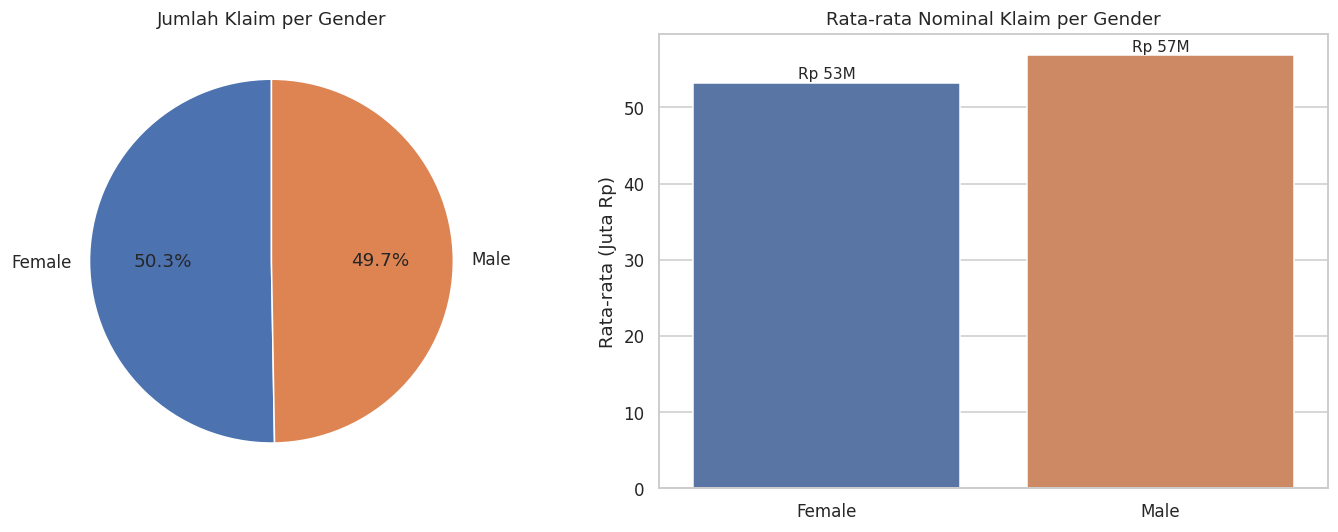

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Jumlah klaim per gender
gender_count = df['Gender'].value_counts()
gender_labels = {'M': 'Male', 'F': 'Female'}
gc = gender_count.rename(index=gender_labels)
axes[0].pie(gc, labels=gc.index, autopct='%1.1f%%', startangle=90,
            colors=['#4C72B0', '#DD8452'])
axes[0].set_title('Jumlah Klaim per Gender')

# Rata-rata nominal per gender
gender_nom = df.groupby('Gender')['Nominal Klaim Yang Disetujui'].mean().rename(index=gender_labels) / 1e6
sns.barplot(x=gender_nom.index, y=gender_nom.values, ax=axes[1], palette=['#4C72B0', '#DD8452'])
axes[1].set_title('Rata-rata Nominal Klaim per Gender')
axes[1].set_ylabel('Rata-rata (Juta Rp)')
axes[1].set_xlabel('')
for bar, val in zip(axes[1].patches, gender_nom.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'Rp {val:,.0f}M', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Insight Gender:**
- Distribusi klaim antara Male dan Female relatif **seimbang** dari sisi jumlah
- Namun perlu diperhatikan perbedaan **rata-rata nominal** per gender — gender tertentu mungkin cenderung mengajukan klaim dengan nilai lebih tinggi, yang bisa mengindikasikan perbedaan jenis penyakit atau preferensi lokasi RS

### 1.2 Distribusi Usia Pasien

Usia pasien dihitung pada saat tanggal masuk RS. Analisis ini penting untuk memahami **segmen usia mana yang paling banyak mengajukan klaim** dan **berapa besar nilai klaim per segmen usia**.

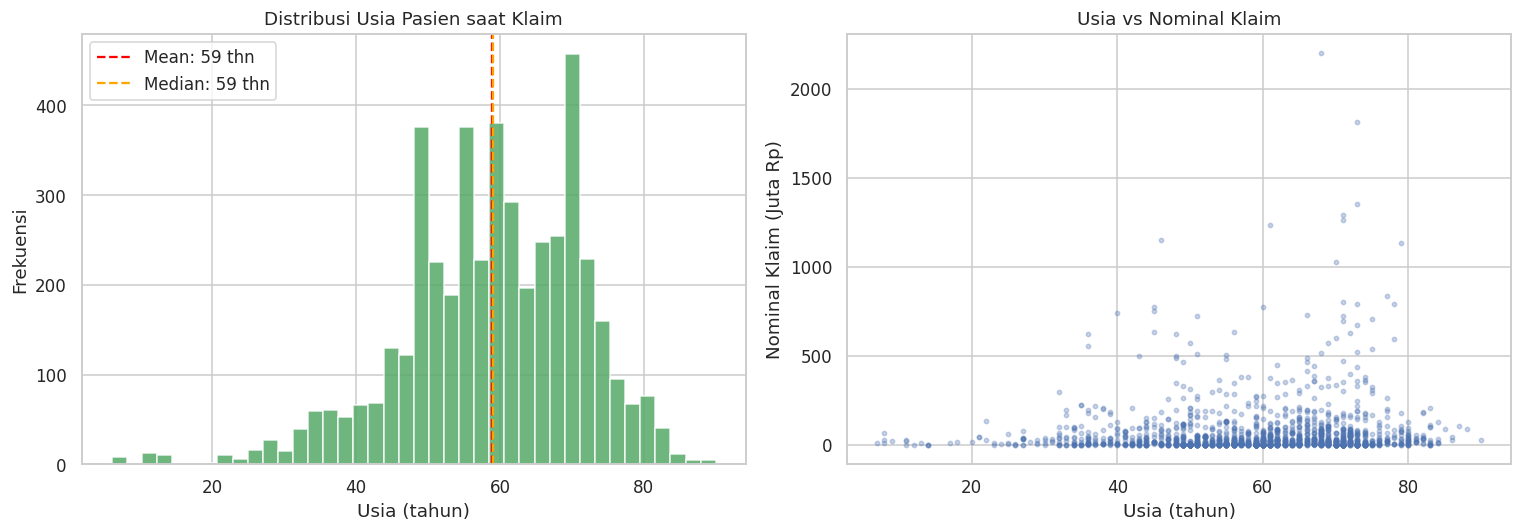

,Kelompok Usia,Jumlah Klaim,Avg Nominal (Juta),Total (Miliar)
0,0-17,38,45.7,1.73
1,18-30,71,30.0,2.13
2,31-45,482,54.3,26.17
3,46-60,1897,37.5,71.08
4,60+,2137,71.8,153.47


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram usia
axes[0].hist(df['Usia'], bins=40, color='#55A868', edgecolor='white', alpha=0.85)
axes[0].axvline(df['Usia'].mean(), color='red', linestyle='--', label=f"Mean: {df['Usia'].mean():.0f} thn")
axes[0].axvline(df['Usia'].median(), color='orange', linestyle='--', label=f"Median: {df['Usia'].median():.0f} thn")
axes[0].set_title('Distribusi Usia Pasien saat Klaim')
axes[0].set_xlabel('Usia (tahun)')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Usia vs Nominal (scatter)
sample = df.sample(min(2000, len(df)), random_state=42)
axes[1].scatter(sample['Usia'], sample['Nominal Klaim Yang Disetujui']/1e6,
               alpha=0.3, s=8, color='#4C72B0')
axes[1].set_title('Usia vs Nominal Klaim')
axes[1].set_xlabel('Usia (tahun)')
axes[1].set_ylabel('Nominal Klaim (Juta Rp)')

plt.tight_layout()
plt.show()

# Stats per kelompok usia
usia_bins = [0, 18, 30, 45, 60, 100]
usia_labels = ['0-17', '18-30', '31-45', '46-60', '60+']
df['Kelompok_Usia'] = pd.cut(df['Usia'], bins=usia_bins, labels=usia_labels)
usia_stats = df.groupby('Kelompok_Usia', observed=True).agg(
    Jumlah_Klaim=('Claim ID', 'count'),
    Avg_Nominal=('Nominal Klaim Yang Disetujui', 'mean'),
    Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index()
usia_stats['Avg_Nominal'] = (usia_stats['Avg_Nominal']/1e6).round(1)
usia_stats['Total_Nominal'] = (usia_stats['Total_Nominal']/1e9).round(2)
usia_stats.columns = ['Kelompok Usia', 'Jumlah Klaim', 'Avg Nominal (Juta)', 'Total (Miliar)']
usia_stats

**Insight Usia — Temuan Kunci:**

| Kelompok Usia | Jumlah Klaim | Avg Nominal (Juta) | Total (Miliar) | % Total |
|:---:|:---:|:---:|:---:|:---:|
| 0-17 | 38 | 45,7 | 1,73 | 0,7% |
| 18-30 | 71 | 30,0 | 2,13 | 0,8% |
| 31-45 | 482 | 54,3 | 26,17 | 10,3% |
| 46-60 | 1.897 | 37,5 | 71,08 | 27,9% |
| **60+** | **2.137** | **71,8** | **153,47** | **60,3%** |

**Analisis mendalam:**

1. **Kelompok 60+ mendominasi secara absolut** — baik dari sisi jumlah klaim (46,2%) maupun total nominal (60,3%). Ini konsisten dengan profil risiko asuransi kesehatan dimana lansia memiliki morbiditas lebih tinggi

2. **Rata-rata nominal tertinggi di kelompok 60+** (Rp 71,8 Juta) — hampir **2x lipat** dari kelompok 46-60 (Rp 37,5 Juta). Ini mengindikasikan bahwa selain lebih sering klaim, lansia juga cenderung memerlukan perawatan yang lebih mahal (penyakit degeneratif, kanker, dll)

3. **Kelompok 0-17 menarik**: meskipun jumlah kecil (38 klaim), rata-rata nominalnya cukup tinggi (Rp 45,7 Juta) — kemungkinan didominasi oleh kasus-kasus kongenital atau kondisi serius pada anak

4. **Scatter plot menunjukkan pola fan-out**: semakin tua usia, semakin besar variasi nominal klaim. Ini menunjukkan **heterogenitas kondisi kesehatan** yang meningkat seiring usia

5. **Implikasi bisnis**: ~88% total nominal terkonsentrasi pada usia 46+ — segmen ini memerlukan **pricing dan underwriting** yang lebih ketat

### 1.3 Distribusi per Plan Code

Terdapat 3 jenis plan asuransi: M-001, M-002, dan M-003. Berikut analisis distribusi klaim dan rata-rata nominal per plan.

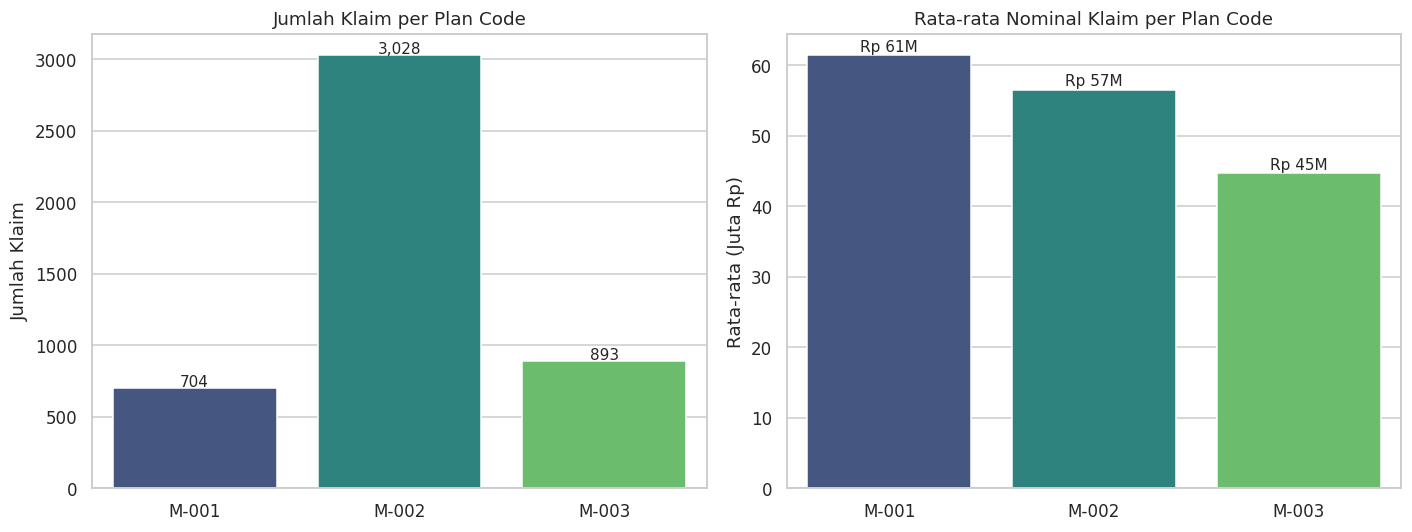

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Jumlah klaim per plan code
plan_count = df['Plan Code'].value_counts().sort_index()
sns.barplot(x=plan_count.index, y=plan_count.values, ax=axes[0], palette='viridis')
axes[0].set_title('Jumlah Klaim per Plan Code')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].set_xlabel('')
for bar, val in zip(axes[0].patches, plan_count.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:,}', ha='center', fontsize=10)

# Avg nominal per plan code
plan_nom = df.groupby('Plan Code')['Nominal Klaim Yang Disetujui'].mean().sort_index() / 1e6
sns.barplot(x=plan_nom.index, y=plan_nom.values, ax=axes[1], palette='viridis')
axes[1].set_title('Rata-rata Nominal Klaim per Plan Code')
axes[1].set_ylabel('Rata-rata (Juta Rp)')
axes[1].set_xlabel('')
for bar, val in zip(axes[1].patches, plan_nom.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'Rp {val:,.0f}M', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

**Insight Plan Code:**
- **M-002 paling banyak digunakan** dengan jumlah klaim tertinggi, menunjukkan ini adalah plan yang paling populer atau memiliki basis nasabah terbesar
- Perbedaan rata-rata nominal antar plan mengindikasikan **tingkat manfaat (benefit)** yang berbeda — plan dengan rata-rata lebih tinggi kemungkinan meng-cover perawatan yang lebih mahal atau memiliki plafon lebih besar

### 1.3.1 distirbusi per plan code dengan normalisasi (rata2 bayar per pasien)

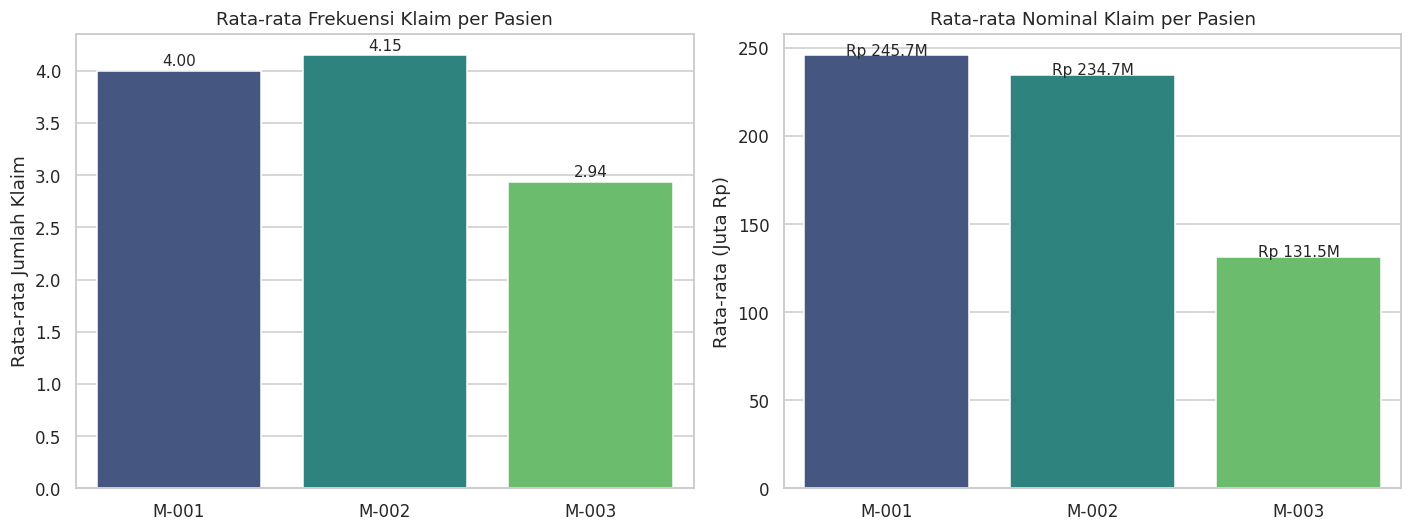

In [5]:
# 1. Lakukan Aggregasi Data
# Kita hitung Total Nominal, Jumlah Klaim, dan Jumlah Pasien Unik per Plan Code
df_agg = df.groupby('Plan Code').agg(
    Jumlah_Klaim=('Nominal Klaim Yang Disetujui', 'count'),
    Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum'),
    Jumlah_Pasien=('Nomor Polis', 'nunique')
).sort_index()

# 2. Hitung Metrik Ternormalisasi (Per Pasien)
# Rata-rata Frekuensi: Seberapa sering 1 pasien melakukan klaim
df_agg['Freq_Klaim_Per_Pasien'] = df_agg['Jumlah_Klaim'] / df_agg['Jumlah_Pasien']

# Rata-rata Nominal per Pasien (Cost per Capita): Rata-rata biaya per 1 pasien
# Kita ubah ke satuan Juta agar mudah dibaca
df_agg['Nominal_Per_Pasien_Juta'] = (df_agg['Total_Nominal'] / df_agg['Jumlah_Pasien']) / 1e6

# 3. Plotting
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Plot 1: Frekuensi Klaim per Pasien ---
sns.barplot(x=df_agg.index, y=df_agg['Freq_Klaim_Per_Pasien'], ax=axes[0], palette='viridis')
axes[0].set_title('Rata-rata Frekuensi Klaim per Pasien')
axes[0].set_ylabel('Rata-rata Jumlah Klaim')
axes[0].set_xlabel('')

# Annotasi Plot 1
for bar, val in zip(axes[0].patches, df_agg['Freq_Klaim_Per_Pasien']):
    # Menggunakan format float 2 desimal (.2f) karena ini adalah rata-rata
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f'{val:.2f}', ha='center', fontsize=10)

# --- Plot 2: Nominal per Pasien (Risk/Cost) ---
sns.barplot(x=df_agg.index, y=df_agg['Nominal_Per_Pasien_Juta'], ax=axes[1], palette='viridis')
axes[1].set_title('Rata-rata Nominal Klaim per Pasien')
axes[1].set_ylabel('Rata-rata (Juta Rp)')
axes[1].set_xlabel('')

# Annotasi Plot 2
for bar, val in zip(axes[1].patches, df_agg['Nominal_Per_Pasien_Juta']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'Rp {val:,.1f}M', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

### Keterangan plan code
<li>M-001: Wilayah pertanggungan Seluruh Dunia (Worldwide).
<li>M-002: Wilayah pertanggungan regional Asia.
<li>M-003: Wilayah pertanggungan domestik Indonesia.
<br>
<b>insight</b>
<li> terlihat bahwa  m-002 (regional asia) memiliki frekuensi claim tertinggi, diikuti dengan m-001 (world wide), dan m-003(Indonesia).
<li> ternyata cakupan worldwide (M-001) memiliki rata2 nominal klaim tertinggi, diikuti dengan regional asia, dan indonesia. ini sejalan dengan biaya plan

### 1.4 Top 15 Domisili (Distribusi Geografis)

Analisis geografis berdasarkan domisili pemegang polis menunjukkan konsentrasi klaim dan biaya di beberapa kota besar.

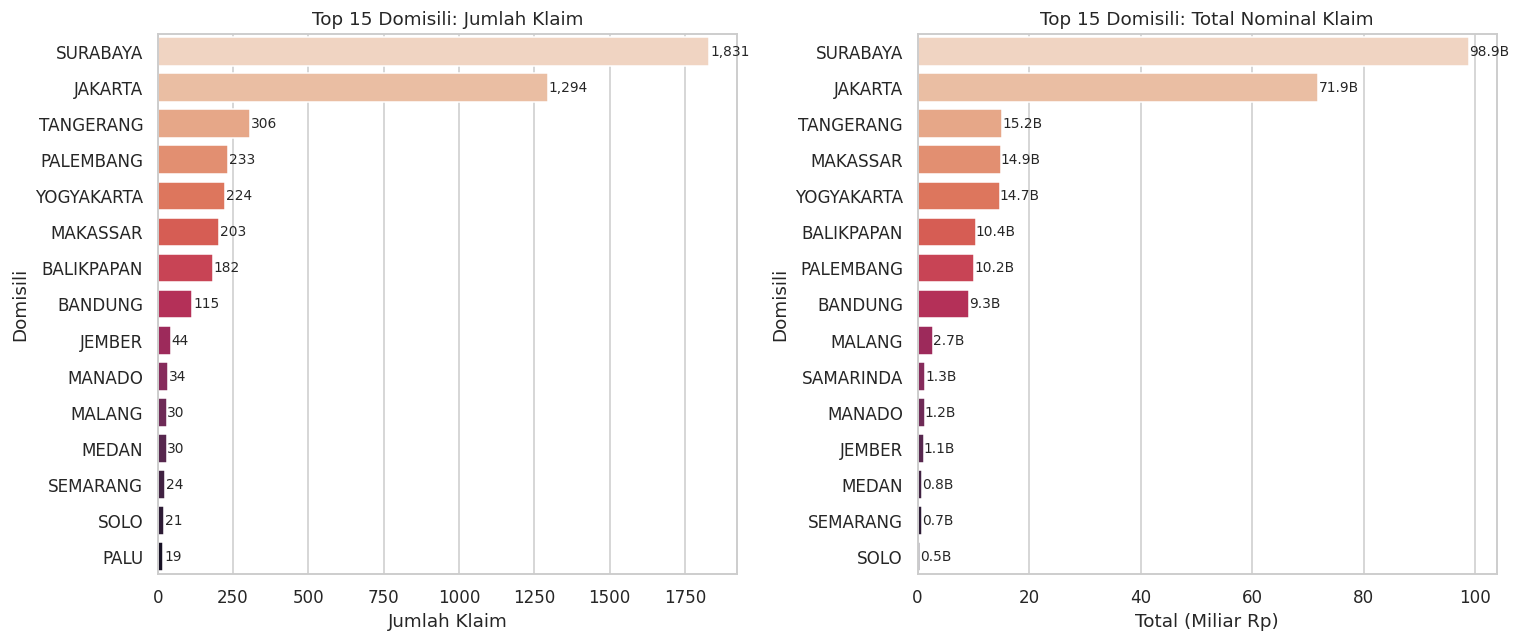

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top 15 domisili by jumlah klaim
dom_count = df['Domisili'].value_counts().head(15)
sns.barplot(y=dom_count.index, x=dom_count.values, ax=axes[0], palette='rocket_r')
axes[0].set_title('Top 15 Domisili: Jumlah Klaim')
axes[0].set_xlabel('Jumlah Klaim')
for bar, val in zip(axes[0].patches, dom_count.values):
    axes[0].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2,
                f'{val:,}', va='center', fontsize=9)

# Top 15 domisili by total nominal
dom_nom = df.groupby('Domisili')['Nominal Klaim Yang Disetujui'].sum().sort_values(ascending=False).head(15) / 1e9
sns.barplot(y=dom_nom.index, x=dom_nom.values, ax=axes[1], palette='rocket_r')
axes[1].set_title('Top 15 Domisili: Total Nominal Klaim')
axes[1].set_xlabel('Total (Miliar Rp)')
for bar, val in zip(axes[1].patches, dom_nom.values):
    axes[1].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}B', va='center', fontsize=9)

plt.tight_layout()
plt.show()

### 1.5.1

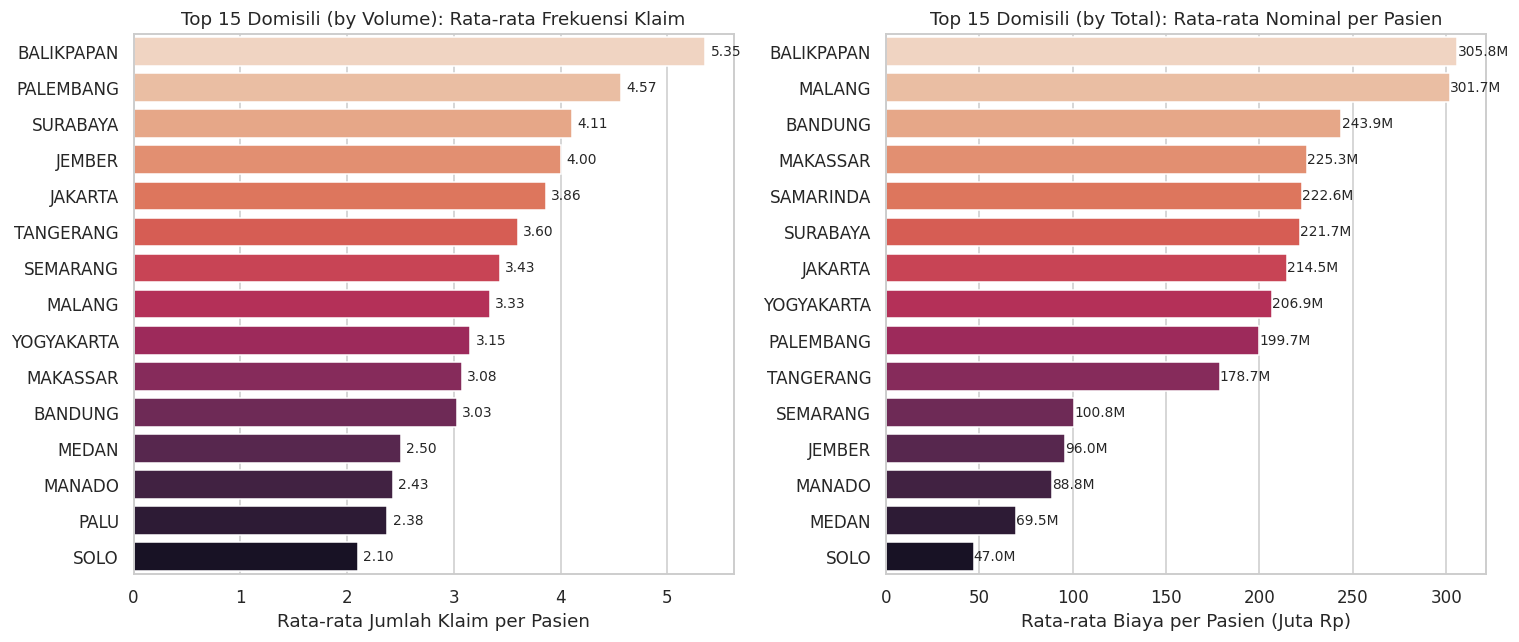

In [7]:
# 1. Aggregasi Data per Domisili
# Kita hitung Total Klaim, Total Nominal, dan Jumlah Pasien Unik
df_dom = df.groupby('Domisili').agg(
    Jumlah_Klaim=('Nominal Klaim Yang Disetujui', 'count'),
    Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum'),
    Jumlah_Pasien=('Nomor Polis', 'nunique')
)

# 2. Hitung Metrik Ternormalisasi
df_dom['Freq_Per_Pasien'] = df_dom['Jumlah_Klaim'] / df_dom['Jumlah_Pasien']
df_dom['Nominal_Per_Pasien_Juta'] = (df_dom['Total_Nominal'] / df_dom['Jumlah_Pasien']) / 1e6

# 3. Filter Top 15
# Top 15 berdasarkan Volume (Jumlah Klaim Terbanyak) untuk grafik pertama
top15_vol = df_dom.nlargest(15, 'Jumlah_Klaim').sort_values('Freq_Per_Pasien', ascending=False)

# Top 15 berdasarkan Total Nominal (Biaya Terbesar) untuk grafik kedua
top15_val = df_dom.nlargest(15, 'Total_Nominal').sort_values('Nominal_Per_Pasien_Juta', ascending=False)

# 4. Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Rata-rata Frekuensi Klaim per Pasien (untuk Top 15 Kota Terpadat) ---
sns.barplot(y=top15_vol.index, x=top15_vol['Freq_Per_Pasien'], ax=axes[0], palette='rocket_r')
axes[0].set_title('Top 15 Domisili (by Volume): Rata-rata Frekuensi Klaim')
axes[0].set_xlabel('Rata-rata Jumlah Klaim per Pasien')
axes[0].set_ylabel('')

# Annotasi Plot 1
for i, (val, name) in enumerate(zip(top15_vol['Freq_Per_Pasien'], top15_vol.index)):
    axes[0].text(val + 0.05, i, f'{val:.2f}', va='center', fontsize=9)

# --- Plot 2: Rata-rata Nominal per Pasien (untuk Top 15 Kota Termahal Secara Total) ---
sns.barplot(y=top15_val.index, x=top15_val['Nominal_Per_Pasien_Juta'], ax=axes[1], palette='rocket_r')
axes[1].set_title('Top 15 Domisili (by Total): Rata-rata Nominal per Pasien')
axes[1].set_xlabel('Rata-rata Biaya per Pasien (Juta Rp)')
axes[1].set_ylabel('')

# Annotasi Plot 2
for i, (val, name) in enumerate(zip(top15_val['Nominal_Per_Pasien_Juta'], top15_val.index)):
    axes[1].text(val + 0.1, i, f'{val:,.1f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Insight Geografis:**
- **Surabaya dan Jakarta** mendominasi baik dari sisi jumlah klaim maupun total nominal — sesuai dengan konsentrasi populasi urban
- Perlu diperhatikan **ranking yang bergeser** antara chart jumlah vs nominal: kota tertentu mungkin memiliki jumlah klaim lebih sedikit tetapi total nominal lebih tinggi (mengindikasikan kasus yang lebih berat atau perawatan yang lebih mahal)
- **Konsentrasi geografis** ini bisa dimanfaatkan untuk strategi **network hospital management** dan **cost containment** regional

- **setelah normalisasi** walaupun surabaya terlihat banyak itu karena mayoritas polis berasal dari domisili surabaya.
<br> setelah di normalisasi, ternyata balikpapan lah yang memiliki rata2 frekuensi klaim tertinggi dan rata2 nominal klaim per pasien tertinggi

### 1.5 Cross-Tabulation: Plan Code × Gender × Lokasi RS

Analisis silang mengungkap interaksi antara jenis plan, gender, dan lokasi RS terhadap rata-rata nominal klaim.

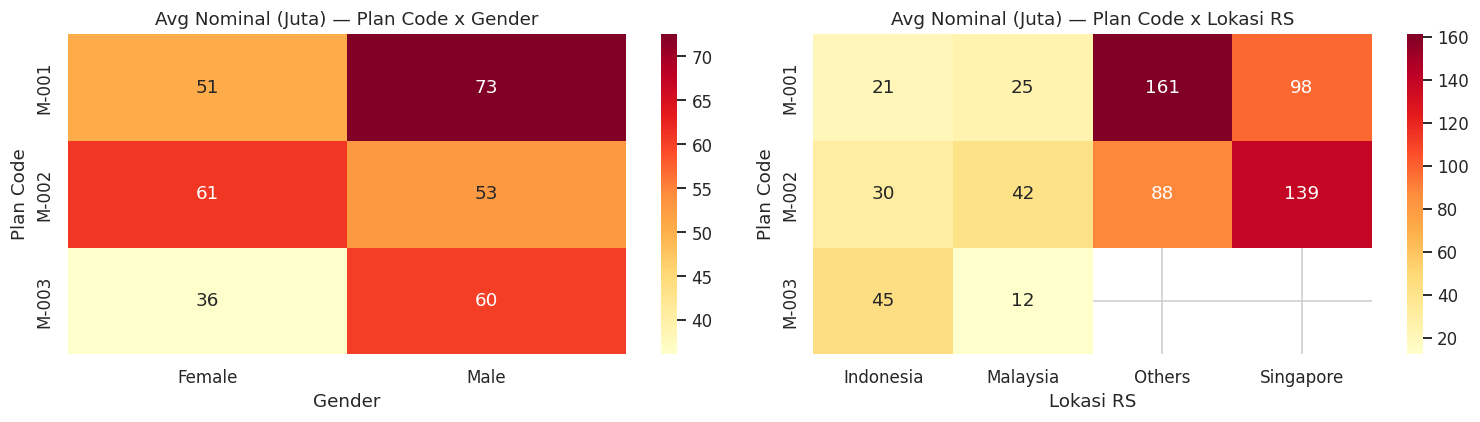

In [8]:
# Heatmap Gender x Plan Code
ct = pd.crosstab(df['Plan Code'], df['Gender'], values=df['Nominal Klaim Yang Disetujui'],
                 aggfunc='mean').rename(columns={'M': 'Male', 'F': 'Female'}) / 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(ct, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('Avg Nominal (Juta) — Plan Code x Gender')

# Heatmap Plan Code x Lokasi RS (top 3 lokasi)
top_lok = df['Lokasi RS'].value_counts().head(3).index
ct2 = pd.crosstab(df['Plan Code'], df['Lokasi RS'].where(df['Lokasi RS'].isin(top_lok), 'Others'),
                  values=df['Nominal Klaim Yang Disetujui'], aggfunc='mean') / 1e6
sns.heatmap(ct2, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('Avg Nominal (Juta) — Plan Code x Lokasi RS')

plt.tight_layout()
plt.show()

**Insight Cross-Tab:**
- Heatmap menunjukkan **variasi signifikan** rata-rata nominal berdasarkan kombinasi plan-gender dan plan-lokasi
- **Lokasi RS adalah faktor dominan** — perbedaan nominal antara Indonesia vs Singapore/overseas jauh lebih besar dibanding perbedaan antar gender
- Kombinasi **plan tertentu + lokasi luar negeri** menghasilkan rata-rata nominal tertinggi — ini bisa menjadi target utama **cost containment**
- **Interaksi gender-plan** relatif moderat, menunjukkan bahwa plan code lebih memengaruhi besaran klaim dibanding gender

---

## Fase 2: Analisis Nominal & Coverage Mendalam

### 2.1 Distribusi Rasio Coverage (Klaim / Biaya RS)

Rasio coverage mengukur seberapa besar asuransi menanggung biaya RS aktual. Rasio = 1 berarti klaim sama persis dengan biaya RS.

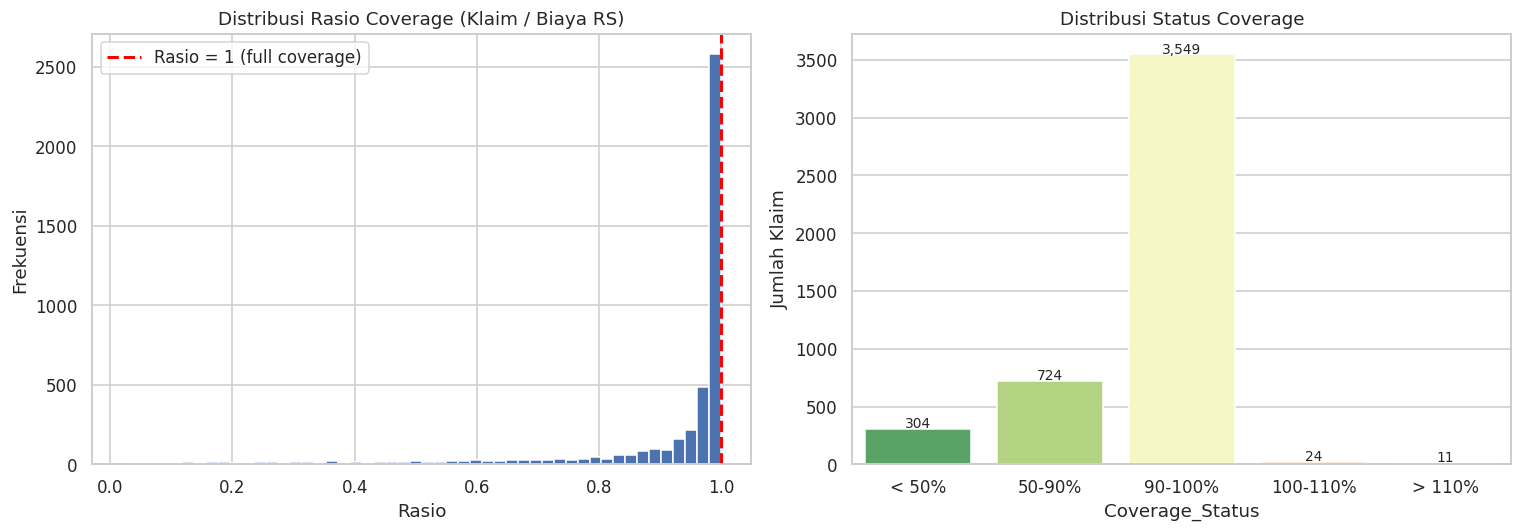

Klaim = Biaya RS  : 1,267 (27.4%)
Klaim < Biaya RS  : 3,322 (71.8%)
Klaim > Biaya RS  : 36 (0.8%)


In [9]:
rasio = df['Rasio_Coverage'].dropna()
rasio_capped = rasio[(rasio > 0) & (rasio <= rasio.quantile(0.99))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(rasio_capped, bins=50, color='#4C72B0', edgecolor='white')
axes[0].axvline(1, color='red', linestyle='--', linewidth=2, label='Rasio = 1 (full coverage)')
axes[0].set_title('Distribusi Rasio Coverage (Klaim / Biaya RS)')
axes[0].set_xlabel('Rasio')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Coverage category
df['Coverage_Status'] = pd.cut(df['Rasio_Coverage'],
    bins=[0, 0.5, 0.9, 1.0, 1.1, np.inf],
    labels=['< 50%', '50-90%', '90-100%', '100-110%', '> 110%'])
cov_count = df['Coverage_Status'].value_counts().sort_index()
sns.barplot(x=cov_count.index, y=cov_count.values, ax=axes[1], palette='RdYlGn_r')
axes[1].set_title('Distribusi Status Coverage')
axes[1].set_ylabel('Jumlah Klaim')
for bar, val in zip(axes[1].patches, cov_count.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                f'{val:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Klaim = Biaya RS  : {(df["Selisih_Klaim"] == 0).sum():,} ({(df["Selisih_Klaim"] == 0).mean()*100:.1f}%)')
print(f'Klaim < Biaya RS  : {(df["Selisih_Klaim"] < 0).sum():,} ({(df["Selisih_Klaim"] < 0).mean()*100:.1f}%)')
print(f'Klaim > Biaya RS  : {(df["Selisih_Klaim"] > 0).sum():,} ({(df["Selisih_Klaim"] > 0).mean()*100:.1f}%)')

**Insight Coverage — Temuan Kritis:**

| Status Coverage | Jumlah | Persentase | Interpretasi |
|:---:|:---:|:---:|:---:|
| Klaim < Biaya RS | 3.322 | 71,8% | **Undercovered** — pasien menanggung selisih |
| Klaim = Biaya RS | 1.267 | 27,4% | **Full coverage** — klaim ditanggung penuh |
| Klaim > Biaya RS | 36 | 0,8% | **Over-coverage** — anomali, perlu investigasi |

**Analisis mendalam:**

1. **Mayoritas (71,8%) klaim bersifat undercovered** — ini menunjukkan bahwa asuransi secara umum **tidak menanggung 100% biaya RS**. Cost-sharing ini bisa berasal dari:
   - Deductible/co-payment dalam polis
   - Biaya yang melebihi plafon/limit plan
   - Item yang tidak di-cover (exclusion)

2. **36 kasus over-coverage** (nominal disetujui > biaya RS) merupakan **red flag** yang perlu investigasi:
   - Bisa jadi perhitungan rate RS berbeda
   - Atau ada komponen non-RS (transport, akomodasi) yang termasuk
   - Beberapa kasus menunjukkan selisih sangat besar (hingga Rp 223 Miliar)

3. **13 klaim dengan nominal Rp 0** — semua bertipe Reimburse (R), menunjukkan kemungkinan:
   - Klaim yang diajukan tapi ditolak/tidak memenuhi syarat
   - Proses reimburse yang belum selesai
   - Error pada data entry

### 2.2 Nominal Klaim per Grup Penyakit (ICD Group)

Analisis ini membandingkan total nominal dan rata-rata nominal per grup penyakit untuk mengidentifikasi **cost driver** utama.

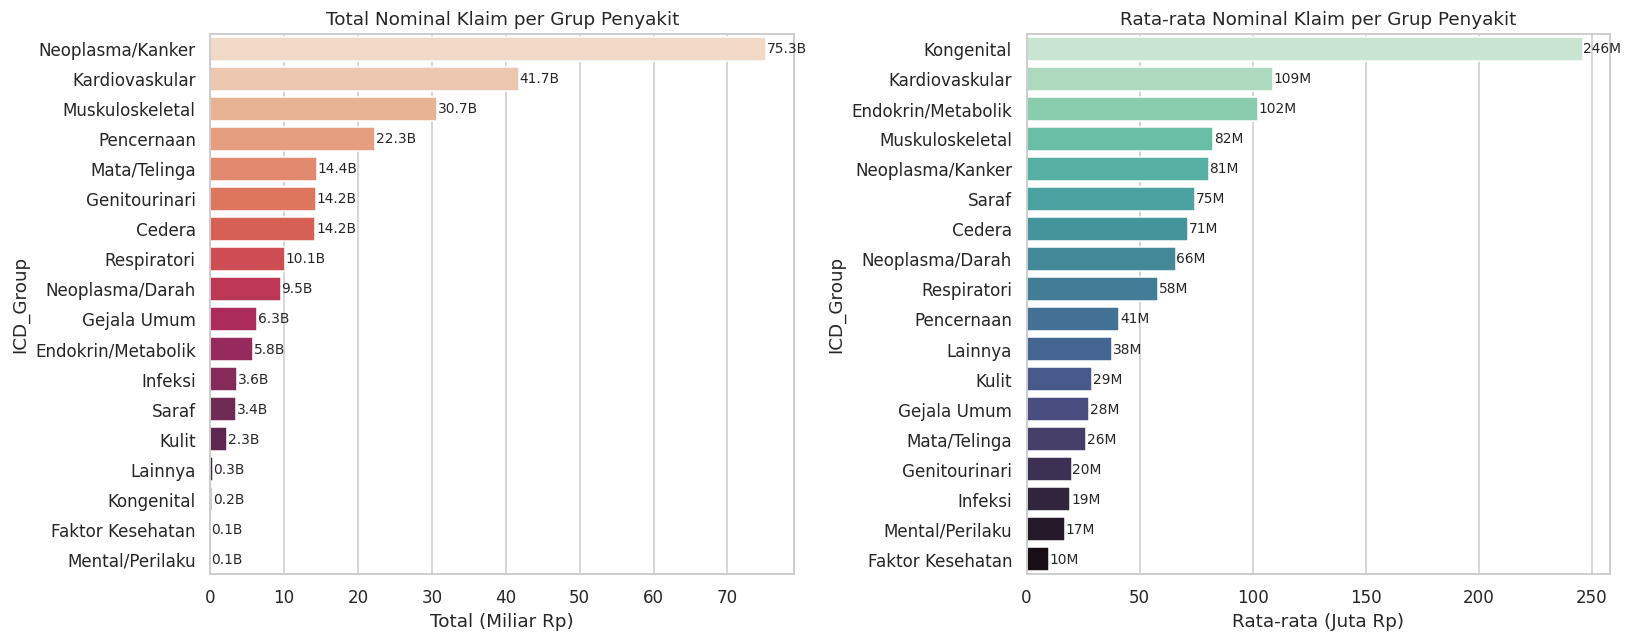

In [10]:
icd_stats = df.groupby('ICD_Group').agg(
    Jumlah=('Claim ID', 'count'),
    Avg_Nominal=('Nominal Klaim Yang Disetujui', 'mean'),
    Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum')
).sort_values('Total_Nominal', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Total nominal per ICD Group
sns.barplot(y=icd_stats.index, x=icd_stats['Total_Nominal']/1e9, ax=axes[0], palette='rocket_r')
axes[0].set_title('Total Nominal Klaim per Grup Penyakit')
axes[0].set_xlabel('Total (Miliar Rp)')
for bar, val in zip(axes[0].patches, icd_stats['Total_Nominal']/1e9):
    axes[0].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}B', va='center', fontsize=9)

# Avg nominal per ICD Group
icd_avg = icd_stats.sort_values('Avg_Nominal', ascending=False)
sns.barplot(y=icd_avg.index, x=icd_avg['Avg_Nominal']/1e6, ax=axes[1], palette='mako_r')
axes[1].set_title('Rata-rata Nominal Klaim per Grup Penyakit')
axes[1].set_xlabel('Rata-rata (Juta Rp)')
for bar, val in zip(axes[1].patches, icd_avg['Avg_Nominal']/1e6):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.0f}M', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Insight Cost Driver per Grup Penyakit:**

- **Neoplasma/Kanker** adalah cost driver nomor satu baik dari sisi **total nominal** maupun frekuensi — ini konsisten dengan fakta bahwa pengobatan kanker (kemoterapi, radioterapi, pembedahan) membutuhkan biaya sangat tinggi dan perawatan berulang

- **Perhatikan perbedaan ranking total vs rata-rata:**
  - Grup dengan **total tinggi** = gabungan frekuensi × rata-rata (misalnya Kardiovaskular: banyak kasus dengan biaya moderat-tinggi)
  - Grup dengan **rata-rata tinggi** tapi total rendah = kasus jarang tapi sangat mahal (misalnya Kongenital)

- **Implikasi strategis:** Pengelolaan klaim kanker memerlukan **case management khusus** karena sifatnya yang mahal dan berulang

### 2.3 Boxplot: Nominal per Lokasi RS & Jenis Rawat

Perbandingan distribusi nominal klaim berdasarkan lokasi rumah sakit (top 4) dan jenis perawatan.

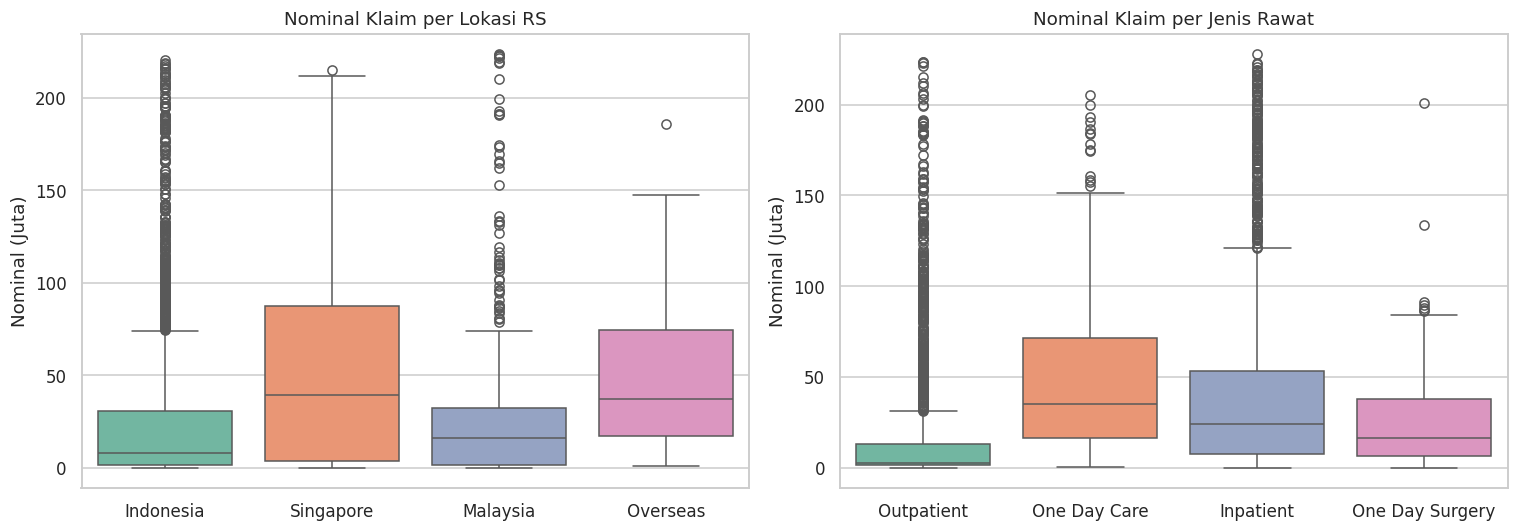

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nominal per Lokasi RS (top 4)
top4_lok = df['Lokasi RS'].value_counts().head(4).index.tolist()
df_lok = df[df['Lokasi RS'].isin(top4_lok)].copy()
df_lok['Nominal (Juta)'] = df_lok['Nominal Klaim Yang Disetujui'] / 1e6
q95 = df_lok['Nominal (Juta)'].quantile(0.95)
sns.boxplot(data=df_lok[df_lok['Nominal (Juta)'] <= q95],
            x='Lokasi RS', y='Nominal (Juta)', ax=axes[0],
            order=['Indonesia', 'Singapore', 'Malaysia', 'Overseas'], palette='Set2')
axes[0].set_title('Nominal Klaim per Lokasi RS')
axes[0].set_xlabel('')

# Nominal per jenis rawat
ip_map = {'IP': 'Inpatient', 'OP': 'Outpatient', 'ODC': 'One Day Care', 'ODS': 'One Day Surgery'}
df_ip = df.dropna(subset=['Inpatient/Outpatient']).copy()
df_ip['Jenis_Rawat'] = df_ip['Inpatient/Outpatient'].map(ip_map)
df_ip['Nominal (Juta)'] = df_ip['Nominal Klaim Yang Disetujui'] / 1e6
q95_ip = df_ip['Nominal (Juta)'].quantile(0.95)
sns.boxplot(data=df_ip[df_ip['Nominal (Juta)'] <= q95_ip],
            x='Jenis_Rawat', y='Nominal (Juta)', ax=axes[1], palette='Set2')
axes[1].set_title('Nominal Klaim per Jenis Rawat')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

**Insight Lokasi RS & Jenis Rawat:**

- **Singapore memiliki median dan IQR nominal tertinggi** — perawatan di Singapura secara konsisten jauh lebih mahal dibandingkan Indonesia. Ini mencakup biaya medis yang memang lebih tinggi plus biaya hidup/akomodasi
- **Overseas** juga menunjukkan nominal tinggi tetapi dengan variasi yang lebih besar
- **Inpatient (IP)** mendominasi dari sisi nominal karena mencakup biaya kamar, tindakan, dan perawatan intensif
- **Outpatient (OP)** memiliki nominal paling rendah sesuai ekspektasi — kunjungan rawat jalan umumnya lebih murah
- **One Day Surgery (ODS)** menunjukkan distribusi yang menarik — bisa setinggi inpatient karena melibatkan prosedur bedah
- Data di-cap pada persentil 95 untuk menghindari distorsi dari outlier ekstrem

---

## Fase 3: Pola Klaim & Repeat Claimers

### 3.1 Distribusi Jumlah Klaim per Polis

Analisis ini mengidentifikasi pola frekuensi klaim dan mengungkap **repeat claimers** — polis yang mengajukan klaim dengan frekuensi sangat tinggi.

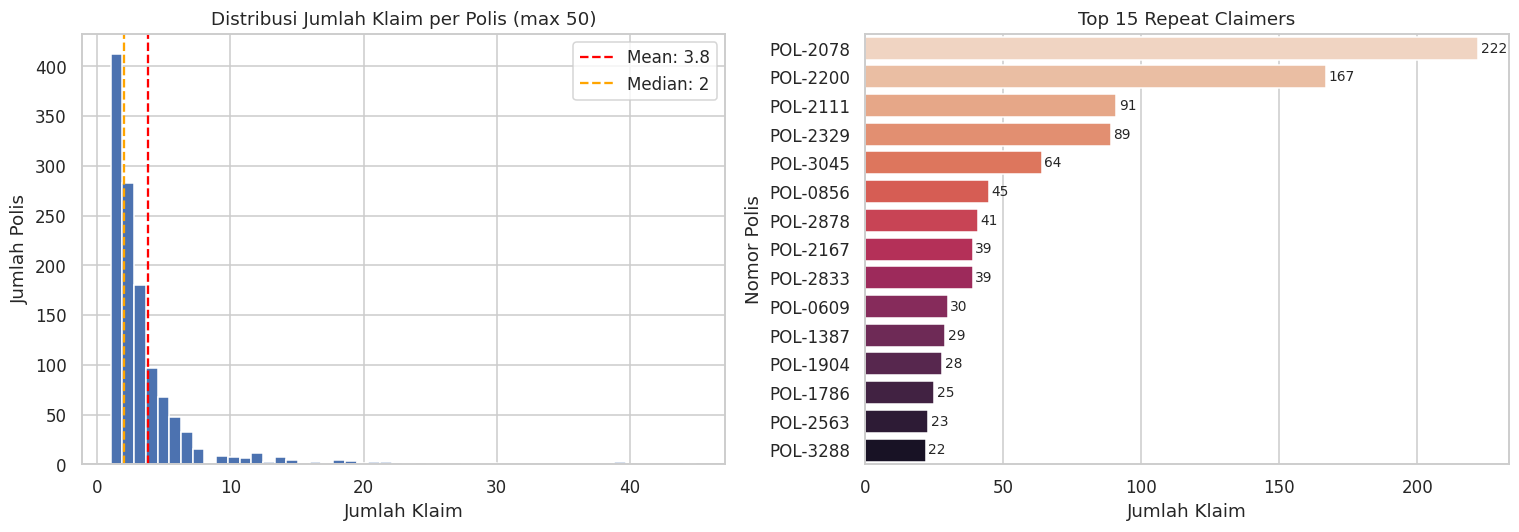

Statistik klaim per polis:
count    1210.000000
mean        3.822314
std         9.652301
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max       222.000000


In [12]:
klaim_per_polis = df['Nomor Polis'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram (capped at 50 for readability)
kpp_cap = klaim_per_polis[klaim_per_polis <= 50]
axes[0].hist(kpp_cap, bins=50, color='#4C72B0', edgecolor='white')
axes[0].set_title('Distribusi Jumlah Klaim per Polis (max 50)')
axes[0].set_xlabel('Jumlah Klaim')
axes[0].set_ylabel('Jumlah Polis')
axes[0].axvline(klaim_per_polis.mean(), color='red', linestyle='--',
               label=f"Mean: {klaim_per_polis.mean():.1f}")
axes[0].axvline(klaim_per_polis.median(), color='orange', linestyle='--',
               label=f"Median: {klaim_per_polis.median():.0f}")
axes[0].legend()

# Top 15 repeat claimers
top15 = klaim_per_polis.head(15)
sns.barplot(y=top15.index, x=top15.values, ax=axes[1], palette='rocket_r')
axes[1].set_title('Top 15 Repeat Claimers')
axes[1].set_xlabel('Jumlah Klaim')
for bar, val in zip(axes[1].patches, top15.values):
    axes[1].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f'Statistik klaim per polis:')
print(klaim_per_polis.describe().to_string())

**Insight Distribusi Klaim per Polis:**

| Statistik | Nilai |
|:---:|:---:|
| Jumlah Polis Unik | 1.210 |
| Mean klaim/polis | 3,82 |
| Median klaim/polis | 2,0 |
| Std Dev | 9,65 |
| Max klaim/polis | **222** |

- **Distribusi sangat right-skewed** — mayoritas polis hanya klaim 1-2 kali (median = 2), namun ada outlier ekstrem hingga 222 klaim
- **Gap mean vs median** (3,82 vs 2,0) menunjukkan bahwa segelintir repeat claimers sangat mempengaruhi rata-rata
- **Top 15 repeat claimers** perlu diinvestigasi lebih lanjut — apakah ini pasien kronis yang legitimate atau potensi fraud

### 3.2 Profil Top 10 Repeat Claimers

Berikut profil detail 10 polis dengan frekuensi klaim tertinggi, mencakup informasi demografis, diagnosis, dan lokasi perawatan.

In [13]:
top10_polis = klaim_per_polis.head(10).index.tolist()
top10_df = df[df['Nomor Polis'].isin(top10_polis)]

profil = top10_df.groupby('Nomor Polis').agg(
    Jumlah_Klaim=('Claim ID', 'count'),
    Total_Nominal=('Nominal Klaim Yang Disetujui', 'sum'),
    Avg_Nominal=('Nominal Klaim Yang Disetujui', 'mean'),
    Gender=('Gender', 'first'),
    Usia=('Usia', 'first'),
    Plan=('Plan Code', 'first'),
    Domisili=('Domisili', 'first'),
    Top_Diagnosis=('ICD_Group', lambda x: x.value_counts().index[0]),
    detail_Diagnosis=('ICD Diagnosis', lambda x: x.value_counts().index[0]),
    Lokasi_Favorit=('Lokasi RS', lambda x: x.value_counts().index[0]),
    Periode=('Tanggal Pasien Masuk RS', lambda x: f"{x.min().strftime('%Y-%m')} s/d {x.max().strftime('%Y-%m')}")
).sort_values('Jumlah_Klaim', ascending=False)
profil['Total_Nominal'] = (profil['Total_Nominal']/1e9).round(2)
profil['Avg_Nominal'] = (profil['Avg_Nominal']/1e6).round(1)
profil.columns = ['Jml Klaim', 'Total (Miliar)', 'Avg (Juta)', 'Gender', 'Usia',
                  'Plan', 'Domisili', 'Diagnosis Utama','Detail Diagnosis', 'Lokasi RS Favorit', 'Periode']
profil

,Jml Klaim,Total (Miliar),Avg (Juta),Gender,Usia,Plan,Domisili,Diagnosis Utama,Detail Diagnosis,Lokasi RS Favorit,Periode
Nomor Polis,,,,,,,,,,,
POL-2078,222,1.73,7.8,M,56,M-002,SURABAYA,Genitourinari,N18.0,Indonesia,2024-01 s/d 2025-07
POL-2200,167,0.40,2.4,F,50,M-003,JAKARTA,Genitourinari,N18.0,Indonesia,2024-01 s/d 2025-07
POL-2111,91,0.59,6.4,F,59,M-002,SURABAYA,Genitourinari,N18.0,Indonesia,2024-10 s/d 2025-07
POL-2329,89,1.89,21.3,M,51,M-002,SURABAYA,Neoplasma/Kanker,C19,Indonesia,2024-01 s/d 2025-07
POL-3045,64,0.10,1.5,M,55,M-002,PALEMBANG,Genitourinari,N18.6,Indonesia,2024-01 s/d 2025-03
POL-0856,45,5.97,132.7,F,50,M-002,SURABAYA,Neoplasma/Kanker,C34.9,Singapore,2024-01 s/d 2025-07
POL-2878,41,2.00,48.8,F,62,M-001,BALIKPAPAN,Neoplasma/Kanker,C90.0,Singapore,2024-02 s/d 2025-06
POL-2167,39,1.01,26.0,F,45,M-002,JAKARTA,Neoplasma/Kanker,C50,Indonesia,2024-01 s/d 2025-07
POL-2833,39,2.35,60.1,F,72,M-002,BALIKPAPAN,Neoplasma/Kanker,C25,Singapore,2024-01 s/d 2025-07


**Profil Repeat Claimers — Analisis Mendalam:**

| Polis | Klaim | Total (Miliar) | Avg (Juta) | Diagnosis | Kode ICD | Lokasi | Insight |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| POL-2078 | 222 | 1,73 | 7,8 | Genitourinari | N18.0 | Indonesia | Gagal ginjal kronik — cuci darah rutin |
| POL-2200 | 167 | 0,40 | 2,4 | Genitourinari | N18.0 | Indonesia | Gagal ginjal kronik — biaya rendah per sesi |
| POL-2111 | 91 | 0,59 | 6,4 | Genitourinari | N18.0 | Indonesia | Pola serupa gagal ginjal |
| POL-2329 | 89 | 1,89 | 21,3 | Neoplasma/Kanker | C19 | Indonesia | Kanker kolorektal — kemo berulang |
| POL-3045 | 64 | 0,10 | 1,5 | Genitourinari | N18.6 | Indonesia | Gagal ginjal — biaya paling rendah |
| POL-0856 | 45 | 5,97 | 132,7 | Neoplasma/Kanker | C34.9 | Singapore | **Kasus termahal** — kanker paru di Singapore |
| POL-2878 | 41 | 2,00 | 48,8 | Neoplasma/Kanker | C90.0 | Singapore | Multiple myeloma di Singapore |
| POL-2167 | 39 | 1,01 | 26,0 | Neoplasma/Kanker | C50 | Indonesia | Kanker payudara |
| POL-2833 | 39 | 2,35 | 60,1 | Neoplasma/Kanker | C25 | Singapore | Kanker pankreas di Singapore |
| POL-0609 | 30 | 1,94 | 64,8 | Neoplasma/Kanker | C34 | Indonesia | Kanker paru |

**Pola yang Terungkap:**

1. **Dua klaster penyakit utama** repeat claimers:
   - **Gagal ginjal kronik (N18.x)** — frekuensi sangat tinggi (91-222 klaim) tapi nominal per klaim rendah (Rp 1,5-7,8 Juta). Ini konsisten dengan **hemodialisis rutin** (cuci darah 2-3x seminggu)
   - **Kanker (C-codes)** — frekuensi sedang (30-89 klaim) tapi nominal per klaim tinggi (Rp 21-133 Juta). Mencerminkan siklus kemoterapi, radioterapi, dan rawat inap berulang

2. **POL-0856 adalah kasus paling mahal**: 45 klaim dengan total Rp 5,97 Miliar (rata-rata Rp 132,7 Juta/klaim) — kanker paru yang dirawat di Singapore. **Satu polis ini menyumbang 2,3% dari total seluruh nominal klaim**

3. **Pola lokasi**: Pasien gagal ginjal memilih Indonesia (hemodialisis lokal), sedangkan pasien kanker cenderung berobat ke Singapore untuk perawatan lanjutan

4. **Semua repeat claimers berusia 45-72 tahun** — konsisten dengan profil penyakit degeneratif dan kanker

5. **Plan M-002 mendominasi** di antara repeat claimers, menunjukkan bahwa plan ini mungkin memiliki benefit yang memfasilitasi perawatan jangka panjang

### 3.3 Breakdown Diagnosis Top 5 Repeat Claimers

Pie chart berikut menunjukkan distribusi diagnosis untuk 5 polis dengan frekuensi klaim tertinggi.

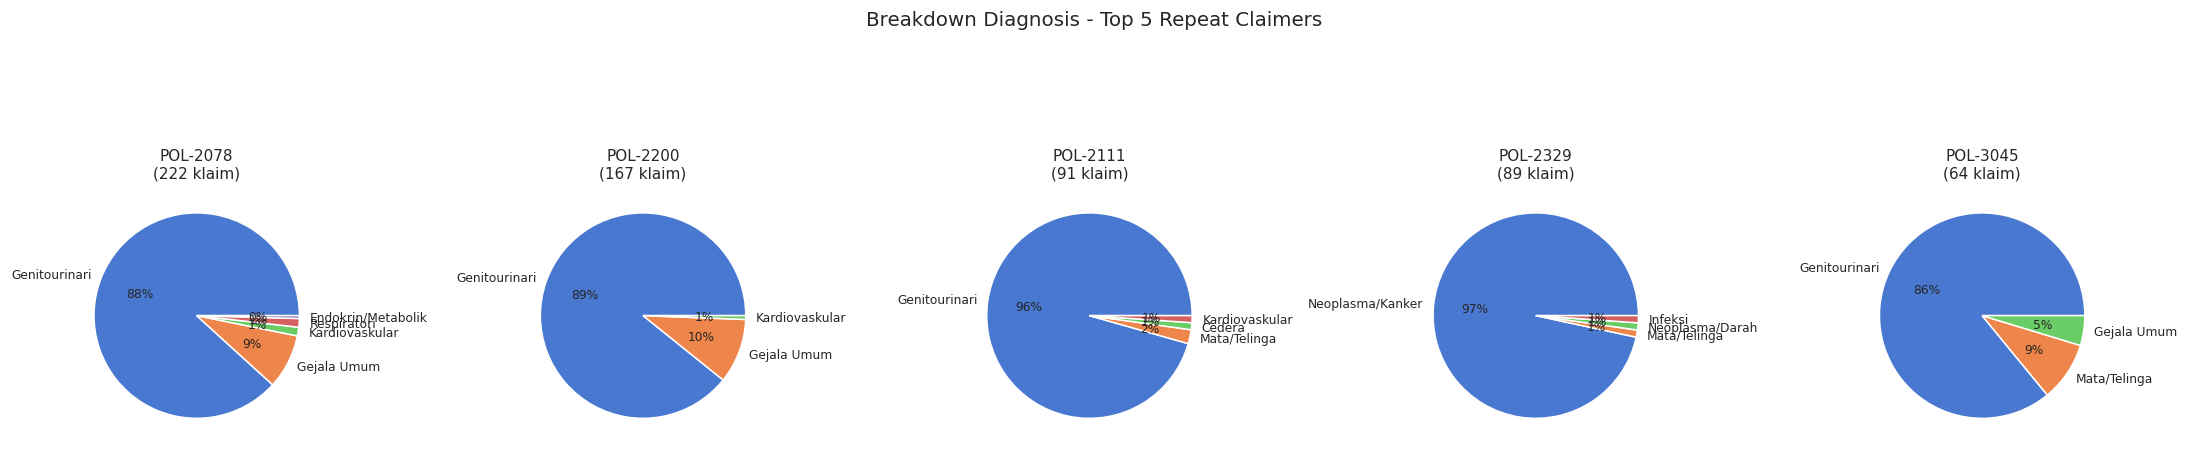

In [14]:
# Top 5 repeat claimers - breakdown diagnosis
top5_polis = klaim_per_polis.head(5).index.tolist()

fig, axes = plt.subplots(1, len(top5_polis), figsize=(20, 5))
for ax, polis in zip(axes, top5_polis):
    data_p = df[df['Nomor Polis'] == polis]
    icd_cnt = data_p['ICD_Group'].value_counts().head(5)
    ax.pie(icd_cnt, labels=icd_cnt.index, autopct='%1.0f%%', textprops={'fontsize': 8})
    ax.set_title(f'{polis}\n({len(data_p)} klaim)', fontsize=10)

plt.suptitle('Breakdown Diagnosis - Top 5 Repeat Claimers', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Insight Diagnosis Pattern:**
- **Pasien kronis cenderung terkonsentrasi pada 1-2 diagnosis utama** — terutama untuk gagal ginjal (Genitourinari) yang mendominasi hampir 100% klaim pada POL-2078, POL-2200, dan POL-2111
- Konsentrasi diagnosis ini **mendukung legitimasi** klaim sebagai pasien kronis, bukan indikasi fraud
- Namun tetap perlu **audit berkala** untuk memastikan frekuensi klaim sesuai dengan protokol medis

### 3.4 Frekuensi Klaim per Plan Code

Perbandingan pola frekuensi klaim antar jenis plan asuransi.

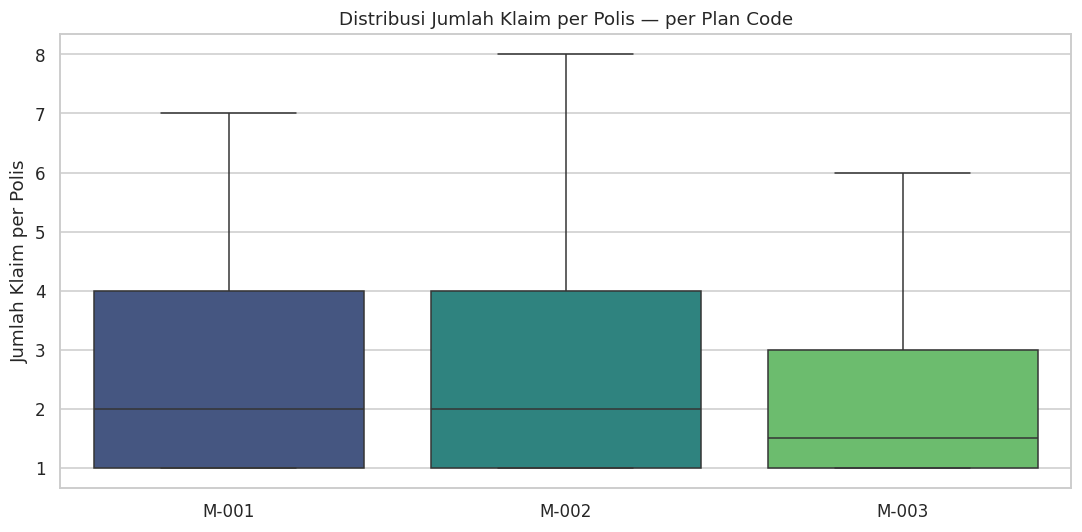

,Mean Klaim/Polis,Median,Max,Jumlah Polis
Plan Code,,,,
M-001,4.0,2.0,41,176
M-002,4.1,2.0,222,730
M-003,2.9,1.5,167,304


In [15]:
kpp_plan = df.groupby(['Nomor Polis', 'Plan Code']).size().reset_index(name='Jumlah_Klaim')

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=kpp_plan, x='Plan Code', y='Jumlah_Klaim', ax=ax, palette='viridis',
           showfliers=False)
ax.set_title('Distribusi Jumlah Klaim per Polis — per Plan Code')
ax.set_ylabel('Jumlah Klaim per Polis')
ax.set_xlabel('')

# Stats table
plan_freq = kpp_plan.groupby('Plan Code')['Jumlah_Klaim'].agg(['mean', 'median', 'max', 'count'])
plan_freq.columns = ['Mean Klaim/Polis', 'Median', 'Max', 'Jumlah Polis']
plan_freq['Mean Klaim/Polis'] = plan_freq['Mean Klaim/Polis'].round(1)

plt.tight_layout()
plt.show()
plan_freq

**Insight Frekuensi per Plan:**

| Plan Code | Mean Klaim/Polis | Median | Max | Jumlah Polis |
|:---:|:---:|:---:|:---:|:---:|
| M-001 | 4,0 | 2,0 | 41 | 176 |
| M-002 | 4,1 | 2,0 | 222 | 730 |
| M-003 | 2,9 | 1,5 | 167 | 304 |

- **M-002** memiliki basis polis terbesar (730) dan outlier tertinggi (222 klaim) — plan ini perlu pengawasan khusus terhadap repeat claimers
- **M-003** memiliki mean dan median terendah, menunjukkan penggunaan yang lebih moderat
- **Median 1,5-2,0 di semua plan** menunjukkan bahwa mayoritas nasabah menggunakan asuransi secara normal

---

## Fase 4: Analisis Temporal (Time Series)

### 4.1 Tren Bulanan: Indonesia vs Luar Negeri

Perbandingan tren jumlah klaim dan total nominal antara perawatan domestik dan luar negeri.

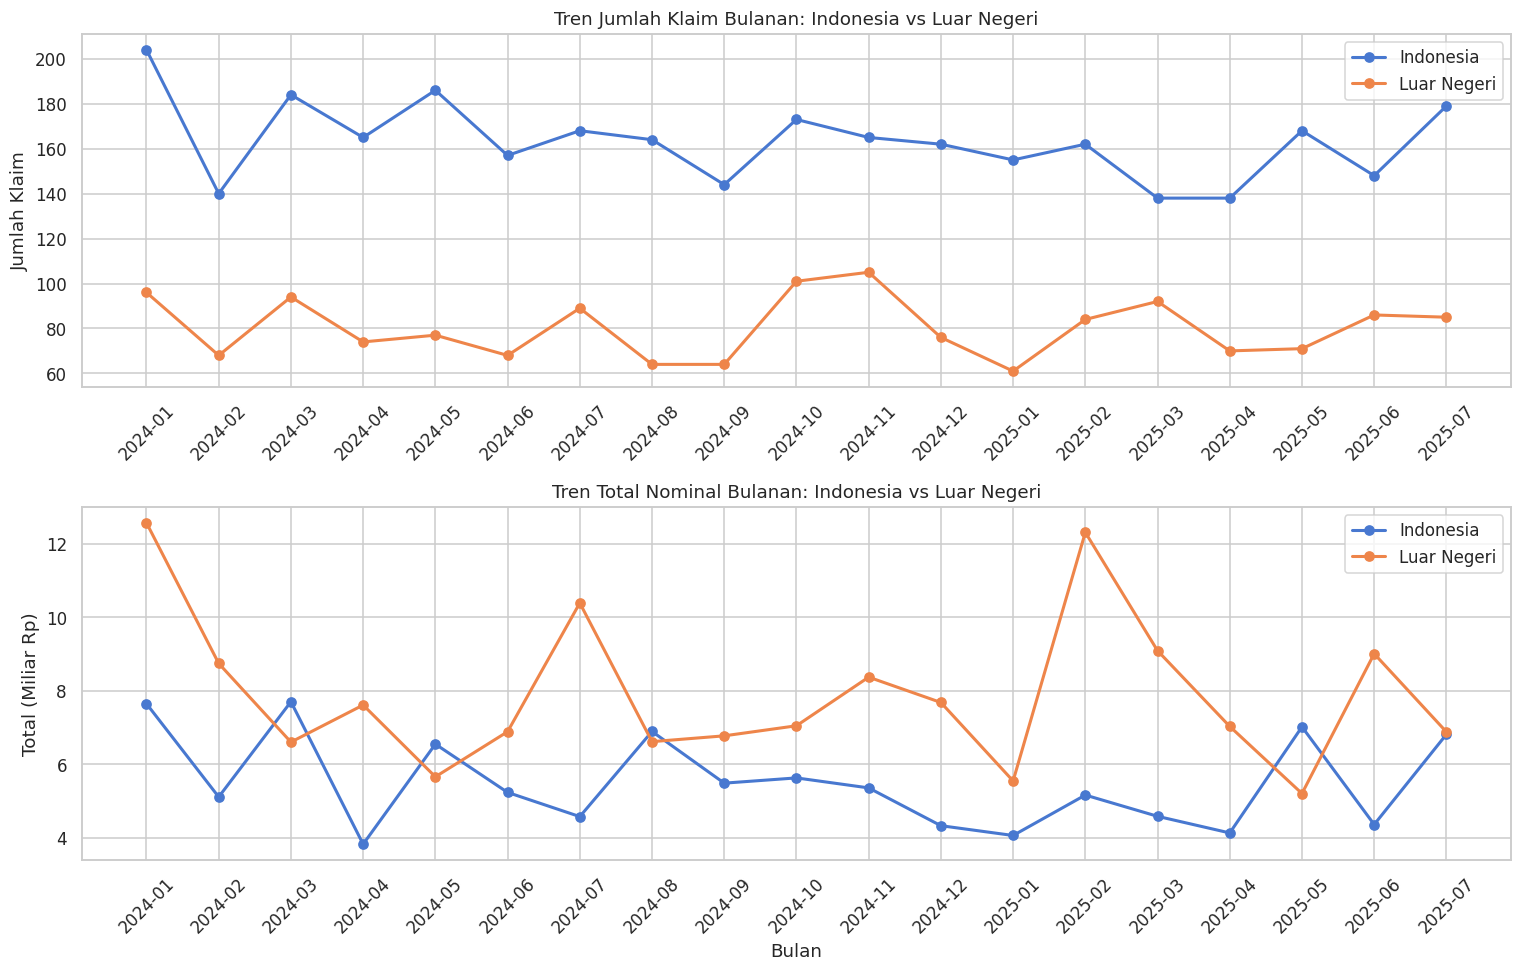

In [16]:
# Tren per lokasi (Indonesia vs Luar Negeri)
trend_lok = df.groupby(['Bulan', 'Lokasi_Group']).agg(
    Jumlah=('Claim ID', 'count'),
    Total=('Nominal Klaim Yang Disetujui', 'sum')
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

for lokasi in ['Indonesia', 'Luar Negeri']:
    data = trend_lok[trend_lok['Lokasi_Group'] == lokasi]
    axes[0].plot(data['Bulan'], data['Jumlah'], marker='o', label=lokasi, linewidth=2)
    axes[1].plot(data['Bulan'], data['Total']/1e9, marker='o', label=lokasi, linewidth=2)

axes[0].set_title('Tren Jumlah Klaim Bulanan: Indonesia vs Luar Negeri')
axes[0].set_ylabel('Jumlah Klaim')
axes[0].legend()
axes[0].tick_params(axis='x', rotation=45)

axes[1].set_title('Tren Total Nominal Bulanan: Indonesia vs Luar Negeri')
axes[1].set_ylabel('Total (Miliar Rp)')
axes[1].set_xlabel('Bulan')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Insight Tren Indonesia vs Luar Negeri:**
- **Indonesia** mendominasi dari sisi jumlah klaim, namun **Luar Negeri** bisa menyamai atau melebihi dari sisi total nominal di bulan-bulan tertentu
- Ini menunjukkan bahwa meskipun klaim luar negeri **jumlahnya lebih sedikit**, nilainya **jauh lebih tinggi per klaim**
- Fluktuasi bulanan pada klaim luar negeri bisa jadi dipengaruhi oleh **siklus pengobatan** (misalnya jadwal kemoterapi di Singapore)
- Tren ini penting untuk **forecasting** dan **budgeting** klaim

### 4.2 Tren Bulanan per Jenis Rawat

Analisis tren temporal untuk masing-masing jenis perawatan (Inpatient, Outpatient, One Day Care, One Day Surgery).

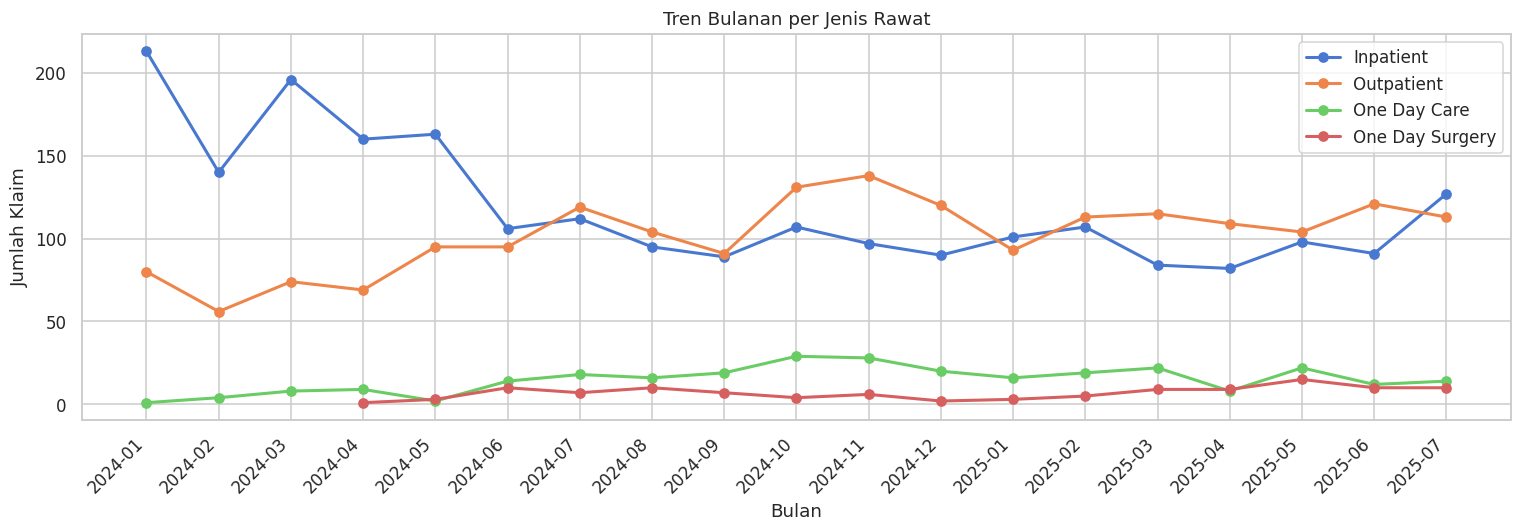

In [17]:
trend_ip = df.dropna(subset=['Inpatient/Outpatient']).groupby(
    ['Bulan', 'Inpatient/Outpatient']).size().reset_index(name='Jumlah')

fig, ax = plt.subplots(figsize=(14, 5))
for jenis in ['IP', 'OP', 'ODC', 'ODS']:
    data = trend_ip[trend_ip['Inpatient/Outpatient'] == jenis]
    label = {'IP': 'Inpatient', 'OP': 'Outpatient', 'ODC': 'One Day Care', 'ODS': 'One Day Surgery'}[jenis]
    ax.plot(data['Bulan'], data['Jumlah'], marker='o', label=label, linewidth=2)

ax.set_title('Tren Bulanan per Jenis Rawat')
ax.set_ylabel('Jumlah Klaim')
ax.set_xlabel('Bulan')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Insight Jenis Rawat:**
- **Inpatient (IP)** umumnya mendominasi dalam jumlah klaim karena mencakup rawat inap yang merupakan jenis klaim paling umum
- Tren masing-masing jenis rawat bisa menunjukkan **shifting pattern** — misalnya apakah ada peningkatan One Day Surgery yang mengindikasikan tren ke prosedur minimal invasif
- Fluktuasi musiman perlu dipantau untuk **capacity planning** RS jaringan

### 4.3 Heatmap: Hari Masuk RS vs Bulan

Heatmap berikut menunjukkan pola hari masuk rumah sakit — apakah ada hari tertentu yang lebih sering digunakan untuk klaim.

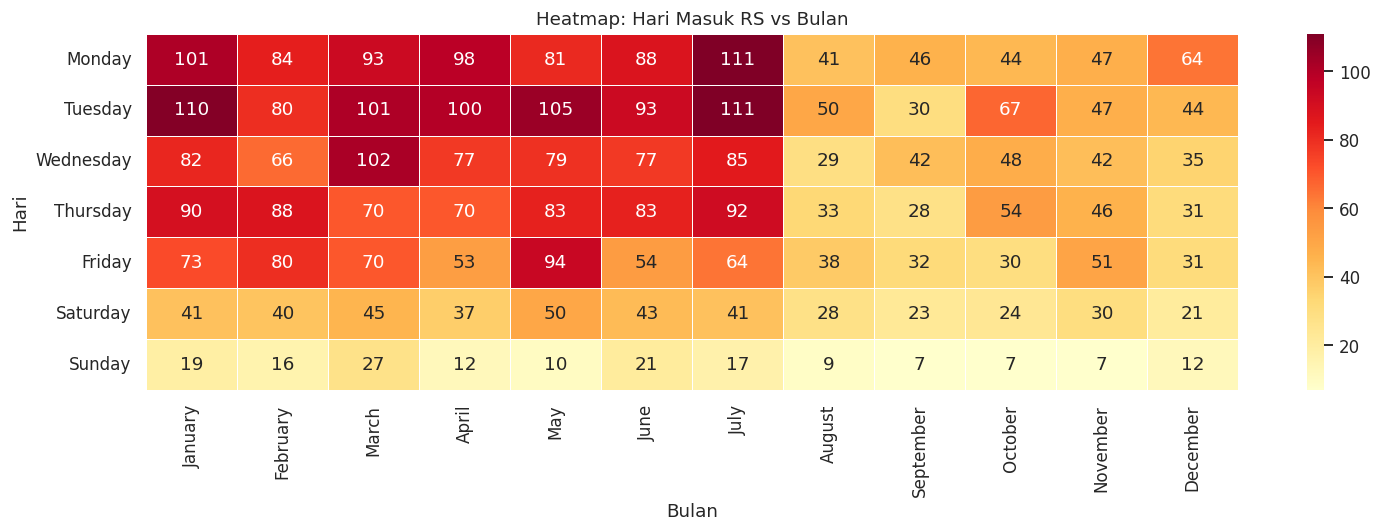

In [18]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = pd.crosstab(df['DayOfWeek'], df['Month'])
# Reorder
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
month_present = [m for m in month_order if m in heatmap_data.columns]
heatmap_data = heatmap_data.reindex(index=day_order, columns=month_present)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Heatmap: Hari Masuk RS vs Bulan')
ax.set_ylabel('Hari')
ax.set_xlabel('Bulan')
plt.tight_layout()
plt.show()

**Insight Heatmap Hari × Bulan:**
- **Hari kerja (Senin-Jumat)** secara konsisten memiliki frekuensi masuk RS lebih tinggi dibanding weekend
- **Sabtu-Minggu** menunjukkan penurunan signifikan — ini logis karena prosedur elektif dan konsultasi terjadwal umumnya dilakukan di hari kerja
- Pola ini bisa digunakan untuk **staffing optimization** tim klaim dan **monitoring real-time** anomali

### 4.4 Claim Processing Time

Processing time adalah durasi dari pasien keluar RS hingga klaim dibayarkan. Ini mengukur efisiensi operasional pemrosesan klaim.

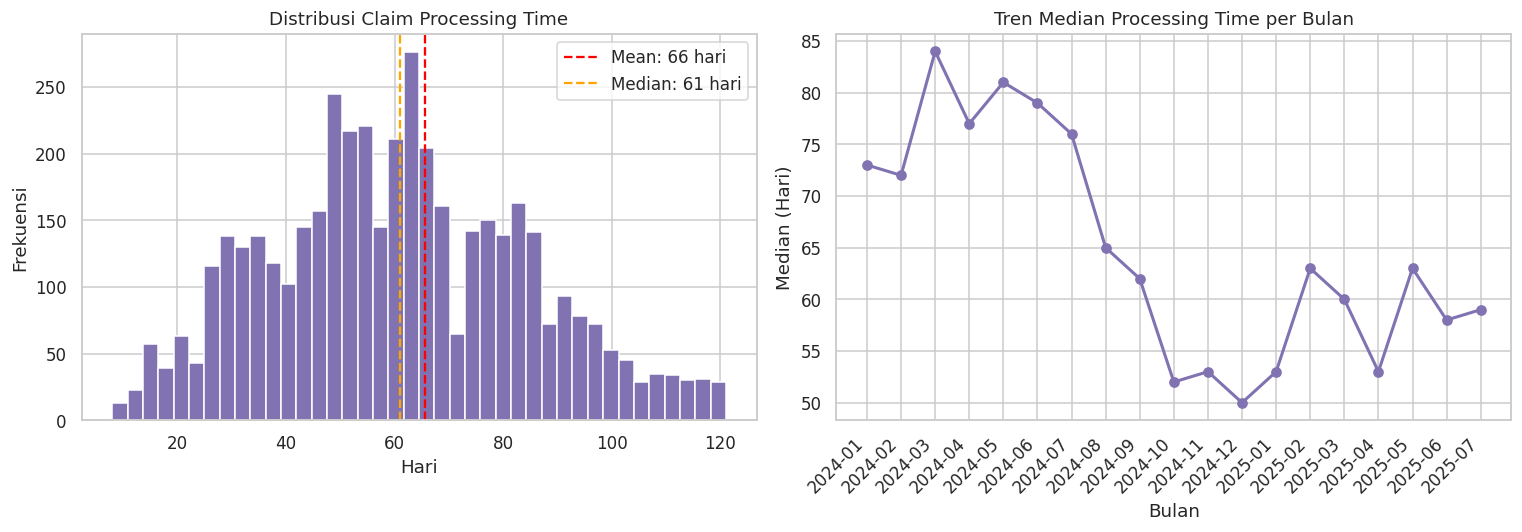

Processing Time Stats:
  Mean   : 66 hari
  Median : 61 hari
  Max    : 606 hari


In [19]:
proc = df.dropna(subset=['Processing_Days']).copy()
proc = proc[proc['Processing_Days'] >= 0]  # filter anomali

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
proc_capped = proc[proc['Processing_Days'] <= proc['Processing_Days'].quantile(0.95)]
axes[0].hist(proc_capped['Processing_Days'], bins=40, color='#8172B2', edgecolor='white')
axes[0].axvline(proc['Processing_Days'].mean(), color='red', linestyle='--',
               label=f"Mean: {proc['Processing_Days'].mean():.0f} hari")
axes[0].axvline(proc['Processing_Days'].median(), color='orange', linestyle='--',
               label=f"Median: {proc['Processing_Days'].median():.0f} hari")
axes[0].set_title('Distribusi Claim Processing Time')
axes[0].set_xlabel('Hari')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Tren bulanan processing time
proc_trend = proc.groupby('Bulan')['Processing_Days'].median().reset_index()
axes[1].plot(proc_trend['Bulan'], proc_trend['Processing_Days'], marker='o', color='#8172B2', linewidth=2)
axes[1].set_title('Tren Median Processing Time per Bulan')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Median (Hari)')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

print(f'Processing Time Stats:')
print(f'  Mean   : {proc["Processing_Days"].mean():.0f} hari')
print(f'  Median : {proc["Processing_Days"].median():.0f} hari')
print(f'  Max    : {proc["Processing_Days"].max():.0f} hari')

**Insight Processing Time:**

- **Median 61 hari, Mean 66 hari** — terdapat gap yang menunjukkan beberapa klaim memerlukan waktu sangat lama
- **Max 606 hari** (~1,7 tahun) — ini merupakan outlier ekstrem yang perlu investigasi (kemungkinan kasus dispute atau klaim kompleks)
- **Tren bulanan** menunjukkan fluktuasi processing time — perlu dipantau apakah ada bulan-bulan tertentu dimana tim klaim kewalahan
- **Target SLA** sebaiknya ditetapkan berdasarkan median (bukan mean) untuk menghindari distorsi dari outlier

### 4.4.1 Processing Time per Grup Penyakit — Tren Temporal (Top 6)

Bagaimana **tren processing time bulanan** untuk masing-masing grup penyakit teratas? Chart dual-axis berikut menampilkan **jumlah klaim** (bar) vs **median processing time** (line) per bulan untuk setiap penyakit, sehingga kita bisa melihat apakah lonjakan volume mempengaruhi kecepatan pemrosesan per diagnosis.

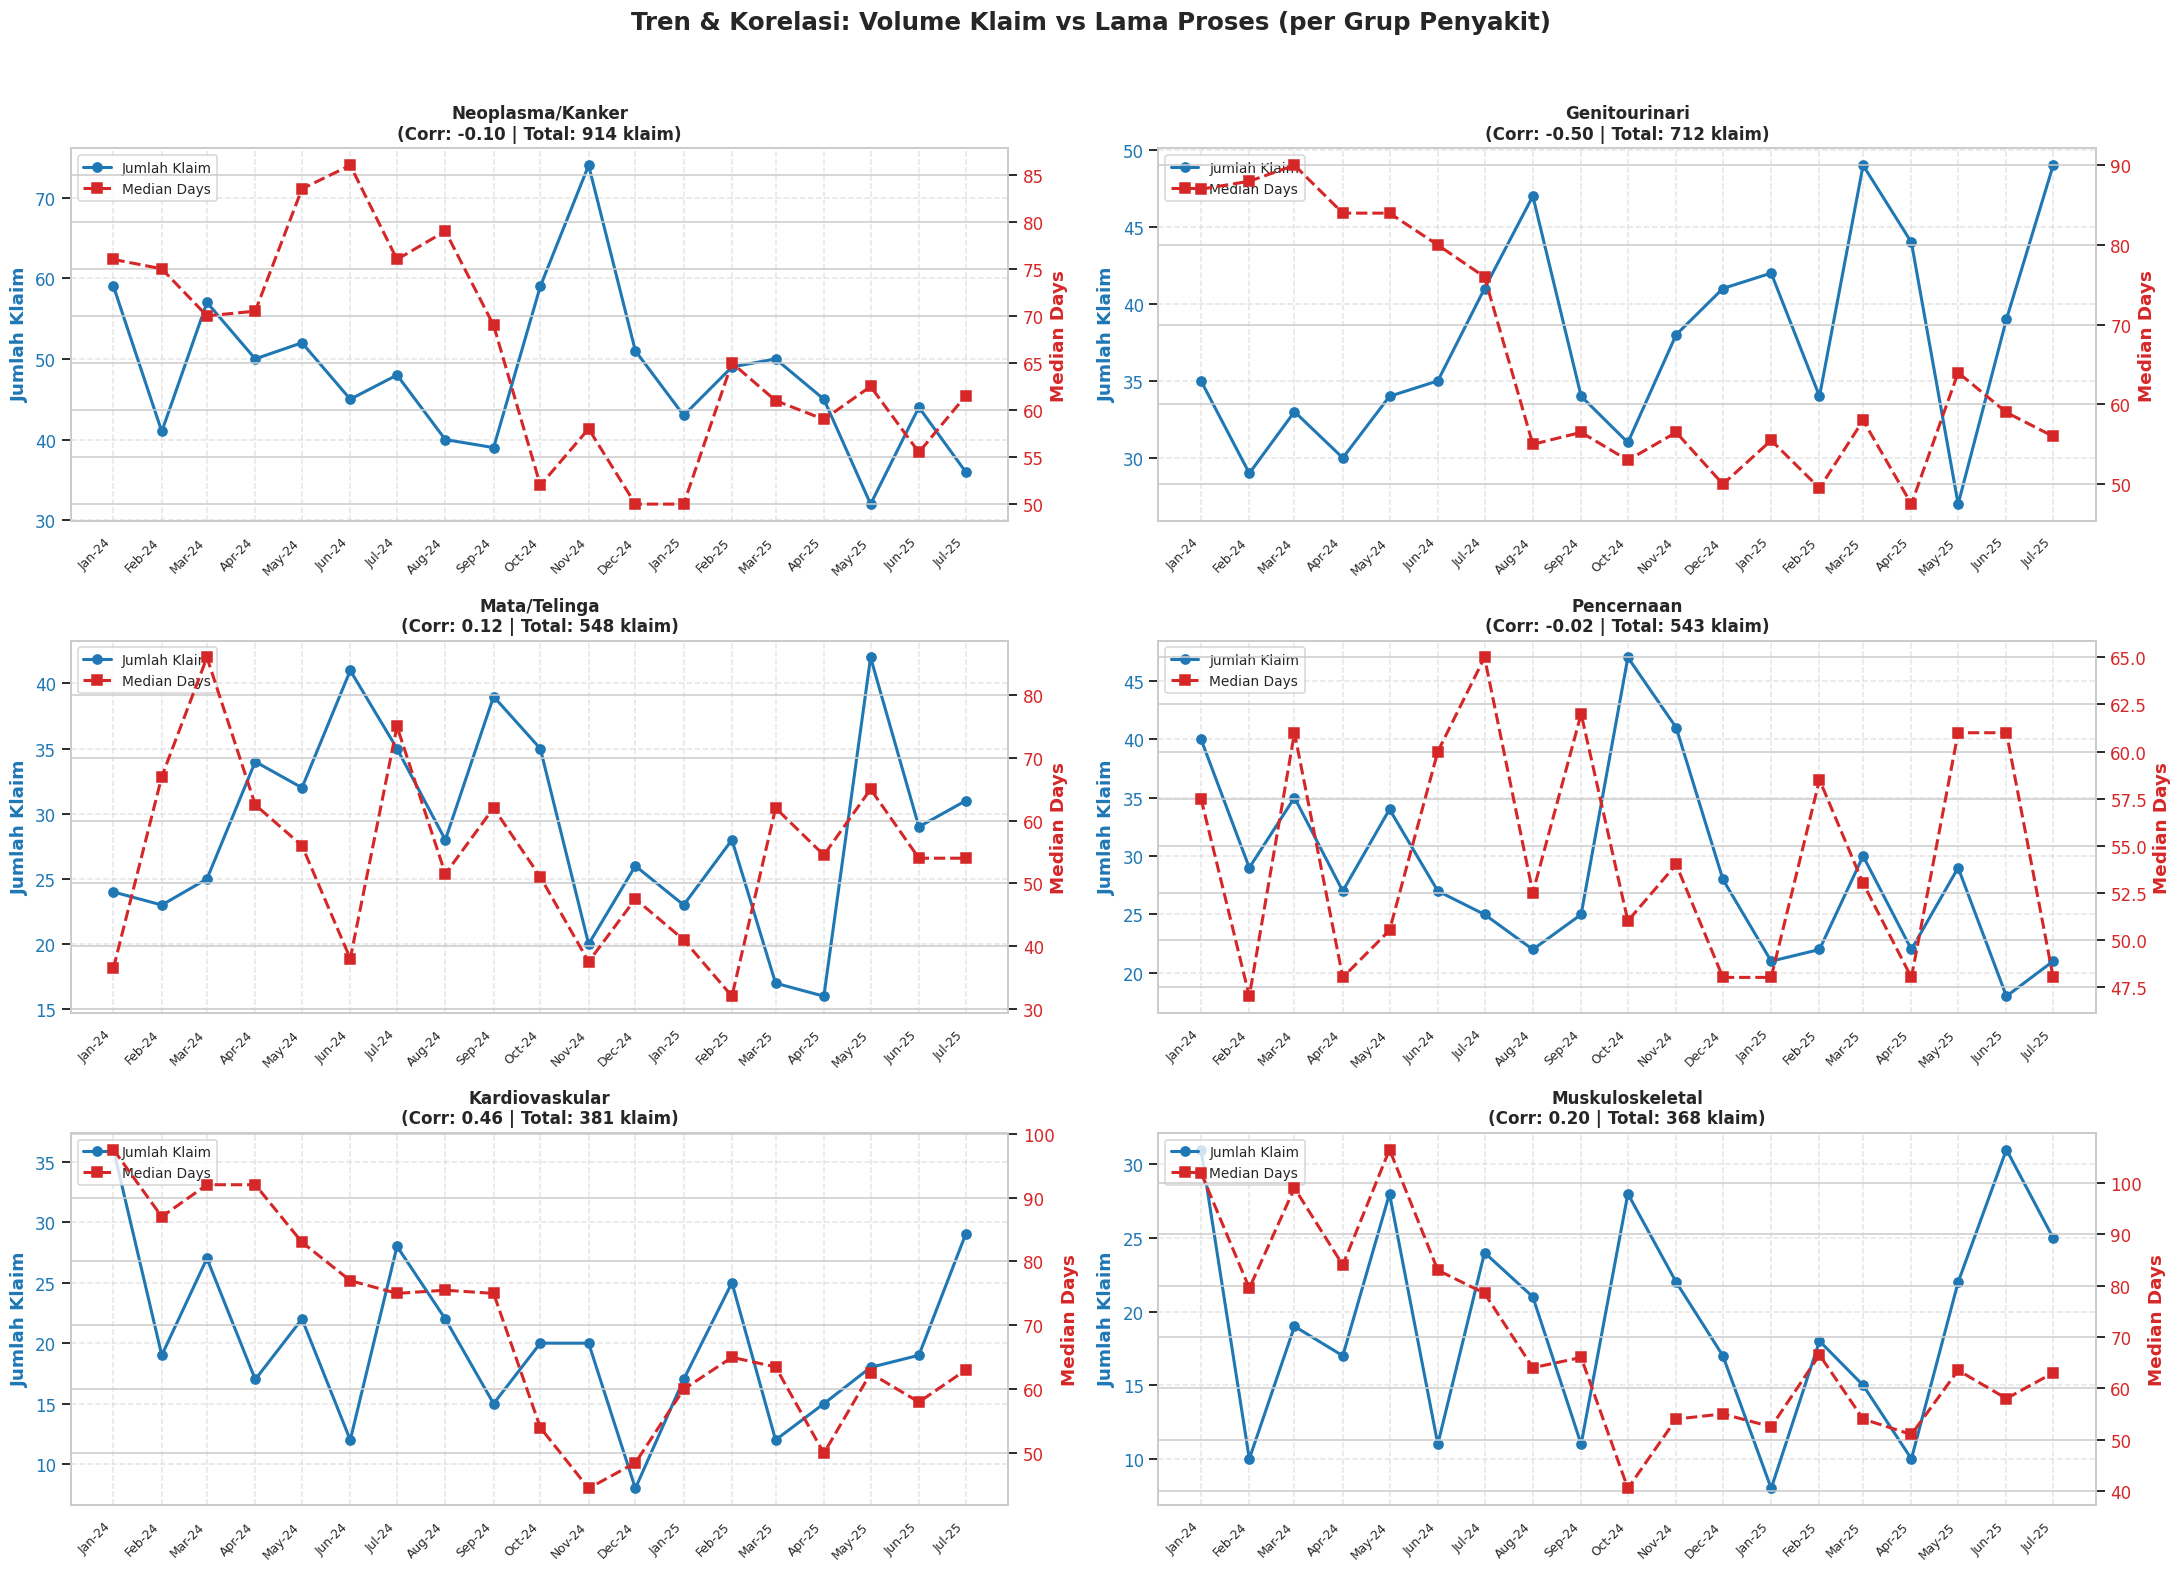

=== Ringkasan Statistik & Korelasi ===


,Total Klaim,Median Hari,Korelasi (r)
ICD Group,,,
Neoplasma/Kanker,914,62.0,-0.10
Genitourinari,712,61.0,-0.50
Mata/Telinga,548,54.0,0.12
Pencernaan,543,54.0,-0.02
Kardiovaskular,381,65.0,0.46
Muskuloskeletal,368,65.0,0.20


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Pastikan data 'proc' sudah siap (seperti di kode awal Anda)
# proc = df.dropna(subset=['Processing_Days']).copy()
# proc['Bulan'] = pd.to_datetime(proc['Bulan']) # Pastikan format datetime

# Ambil Top 6 ICD Group
top6_icd_counts = proc['ICD_Group'].value_counts().head(6)
top6_icd_names = top6_icd_counts.index.tolist()

# Setup Grid Plot 3x2
fig, axes = plt.subplots(3, 2, figsize=(20, 14))
axes = axes.flatten()

# Warna Konsisten
color_claim = '#1f77b4'  # Biru untuk Volume
color_time = '#d62728'   # Merah untuk Waktu Proses

# ... (kode sebelumnya tetap sama)

for i, icd_name in enumerate(top6_icd_names):
    ax1 = axes[i]
    
    # Filter Data per Penyakit
    data_icd = proc[proc['ICD_Group'] == icd_name]
    
    # Agregasi Bulanan
    monthly_stats = data_icd.groupby('Bulan').agg(
        Jumlah=('Claim ID', 'count'),
        Median_Time=('Processing_Days', 'median')
    ).reset_index()
    
    # === PERBAIKAN DI SINI ===
    # Konversi kolom Bulan menjadi datetime object agar bisa di-format
    monthly_stats['Bulan'] = pd.to_datetime(monthly_stats['Bulan']) 
    # =========================

    # Hitung Korelasi (Pearson)
    correlation = monthly_stats['Jumlah'].corr(monthly_stats['Median_Time'])
    
    # --- Plot 1: Jumlah Klaim (Sumbu Kiri - Biru) ---
    line1 = ax1.plot(monthly_stats['Bulan'], monthly_stats['Jumlah'], 
                     marker='o', color=color_claim, linewidth=2, label='Jumlah Klaim')
    
    ax1.set_ylabel('Jumlah Klaim', color=color_claim, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_claim)
    ax1.grid(True, linestyle='--', alpha=0.5)
    
    # --- Plot 2: Processing Time (Sumbu Kanan - Merah) ---
    ax2 = ax1.twinx()
    line2 = ax2.plot(monthly_stats['Bulan'], monthly_stats['Median_Time'], 
                     marker='s', color=color_time, linewidth=2, linestyle='--', label='Median Days')
    
    ax2.set_ylabel('Median Days', color=color_time, fontweight='bold')
    ax2.tick_params(axis='y', labelcolor=color_time)
    
    # Judul dengan Info Korelasi
    ax1.set_title(f'{icd_name}\n(Corr: {correlation:.2f} | Total: {len(data_icd):,} klaim)', 
                  fontsize=11, fontweight='bold')

    # Gabungkan Legend
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', fontsize=9)
    
    # Format Tanggal Sumbu X (Sekarang sudah aman karena tipe datanya datetime)
    ax1.set_xticks(monthly_stats['Bulan']) 
    ax1.set_xticklabels([dt.strftime('%b-%y') for dt in monthly_stats['Bulan']], rotation=45, ha='right', fontsize=8)

plt.suptitle('Tren & Korelasi: Volume Klaim vs Lama Proses (per Grup Penyakit)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
# --- Tabel Ringkasan dengan Kolom Korelasi ---
summary_table = []
for icd in top6_icd_names:
    sub = proc[proc['ICD_Group'] == icd]
    monthly = sub.groupby('Bulan').agg({'Claim ID':'count', 'Processing_Days':'median'})
    corr = monthly['Claim ID'].corr(monthly['Processing_Days'])
    
    summary_table.append({
        'ICD Group': icd,
        'Total Klaim': len(sub),
        'Median Hari': sub['Processing_Days'].median(),
        'Korelasi (r)': round(corr, 2)
    })

df_summary = pd.DataFrame(summary_table).set_index('ICD Group')
print("=== Ringkasan Statistik & Korelasi ===")
display(df_summary)

**Insight Tren Processing Time per Penyakit:**

- **Dual-axis per penyakit** memungkinkan kita melihat apakah di bulan-bulan tertentu, lonjakan volume klaim untuk suatu diagnosis menyebabkan processing time membengkak
- **Neoplasma/Kanker**: Kemungkinan menunjukkan processing time lebih panjang secara konsisten karena melibatkan review medis kompleks, nominal besar, dan sering berasal dari RS luar negeri
- **Kardiovaskular**: Prosedur jantung (PCI, bypass) memerlukan verifikasi biaya tinggi yang memperlambat processing
- **Genitourinari**: Meskipun frekuensi tinggi (hemodialisis rutin), processing time cenderung lebih pendek karena sudah ada **protokol standar** yang memudahkan approval otomatis
- **Bulan-bulan dengan bar tinggi + line naik** = **bottleneck** — tim klaim kewalahan di diagnosis tersebut
- **Bulan-bulan dengan bar tinggi + line turun** = **efisiensi** — volume tinggi namun processing tetap cepat (mungkin ada batch processing)
- Temuan ini mendukung rekomendasi untuk menetapkan **SLA berbeda per diagnosis** sesuai kompleksitas masing-masing

### penyakit dengan claim berulang

In [23]:
df_repeat.head()

,Claim ID,Nomor Polis,Reimburse/Cashless,Inpatient/Outpatient,ICD Diagnosis,ICD Description,Tanggal Pembayaran Klaim,Tanggal Pasien Masuk RS,Tanggal Pasien Keluar RS,Nominal Klaim Yang Disetujui,...,Bulan,Kuartal,DayOfWeek,Kategori_Nominal,ICD_Letter,ICD_Group,Lokasi_Group,Month,Kelompok_Usia,Coverage_Status
0,C-0001-M,POL-0176,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,2024-07-08,2024-05-27,2024-05-27,28093653.0,...,2024-05,2024Q2,Monday,25-100 Juta,C,Neoplasma/Kanker,Luar Negeri,May,46-60,> 110%
1,C-0002-M,POL-3288,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,2024-08-06,2024-07-15,2024-07-15,80987278.0,...,2024-07,2024Q3,Monday,25-100 Juta,C,Neoplasma/Kanker,Luar Negeri,July,60+,90-100%
2,C-0003-M,POL-1786,R,OP,C18.9,"MALIGNANT NEOPLASM, COLON, UNSPECIFIED",2024-10-17,2024-05-16,2024-05-16,183047130.0,...,2024-05,2024Q2,Thursday,> 100 Juta,C,Neoplasma/Kanker,Luar Negeri,May,60+,90-100%
3,C-0004-M,POL-1786,R,OP,C34,MALIGNANT NEOPLASM OF BRONCHUS AND LUNG,2024-09-03,2024-07-18,2024-07-18,191424386.0,...,2024-07,2024Q3,Thursday,> 100 Juta,C,Neoplasma/Kanker,Luar Negeri,July,60+,100-110%
4,C-0005-M,POL-2778,R,OP,C50,MALIGNANT NEOPLASM OF BREAST,NaT,2024-06-06,2024-06-06,138936357.0,...,2024-06,2024Q2,Thursday,> 100 Juta,C,Neoplasma/Kanker,Luar Negeri,June,46-60,90-100%


=== Analisis Klaim Berulang per Penyakit (Chronic Analysis) ===


,Jumlah_Pasien_Berulang,Rata2_Frekuensi_Klaim,Rata2_Biaya_Per_Klaim,Rata2_Jeda_Hari,Est_Total_Cost_Exposure
ICD_Group,,,,,
Pencernaan,147,2.44x,"Rp 34,899,488",49.8 hari,"Rp 12,494,016,714"
Mata/Telinga,131,3.66x,"Rp 29,074,688",29.6 hari,"Rp 13,955,850,304"
Kardiovaskular,94,2.66x,"Rp 108,755,336",62.3 hari,"Rp 27,188,833,902"
Neoplasma/Kanker,86,10.69x,"Rp 108,149,141",52.8 hari,"Rp 99,389,060,661"
Muskuloskeletal,76,3.54x,"Rp 81,867,007",36.7 hari,"Rp 22,022,224,981"
Genitourinari,61,10.95x,"Rp 56,661,050",37.0 hari,"Rp 37,849,581,330"
Cedera,45,2.93x,"Rp 61,327,985",41.9 hari,"Rp 8,095,293,982"
Gejala Umum,37,3.41x,"Rp 21,854,965",53.1 hari,"Rp 2,753,725,597"
Neoplasma/Darah,32,3.19x,"Rp 69,913,482",34.2 hari,"Rp 7,131,175,184"


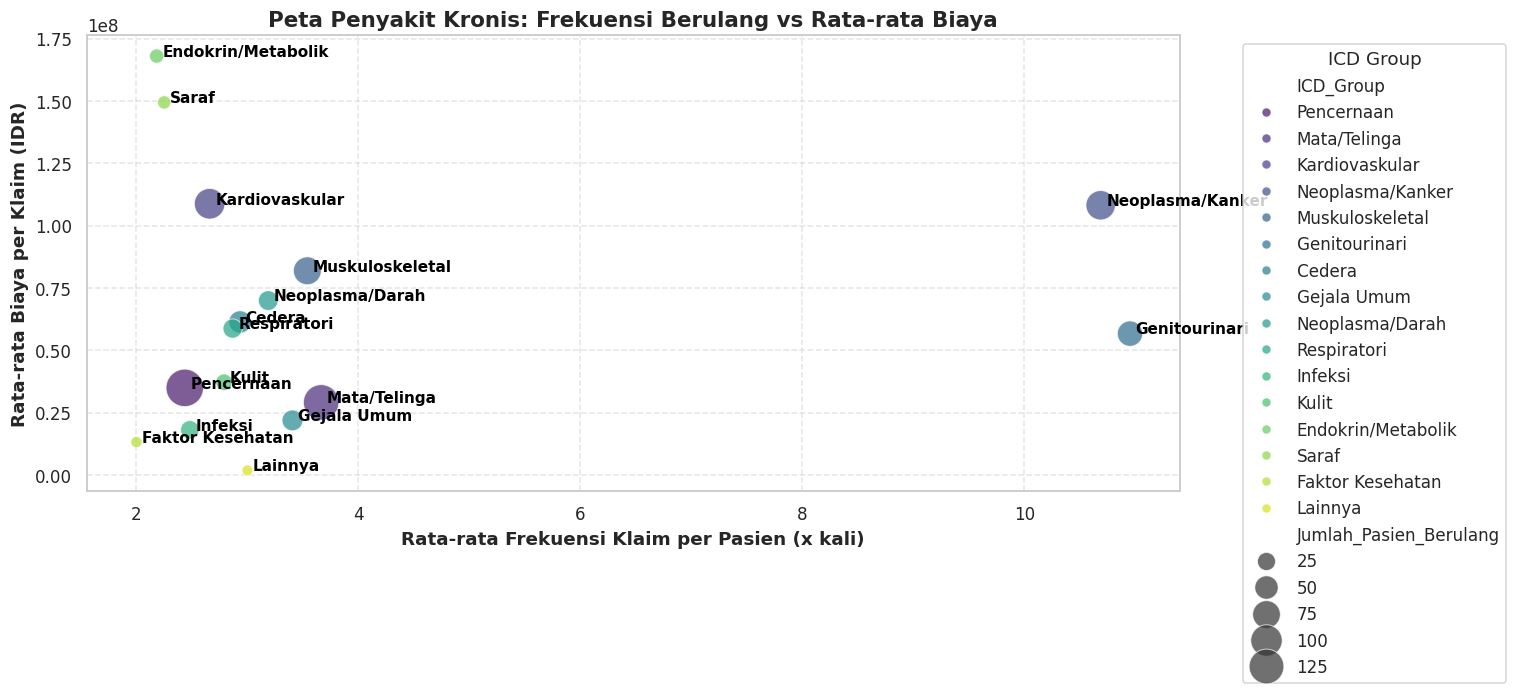

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pastikan Data Siap & Urut Waktu
# Kita gunakan dataframe 'df' (atau 'proc' jika sudah difilter sebelumnya)
df_repeat = df.copy()
df_repeat['Tgl Kejadian'] = pd.to_datetime(df_repeat['Tanggal Pembayaran Klaim'])
df_repeat = df_repeat.sort_values(by=['Nomor Polis', 'ICD_Group', 'Tanggal Pembayaran Klaim'])

# 2. Hitung Jeda Hari (Interval) antar Klaim untuk Polis & Penyakit yang SAMA
df_repeat['Prev_Date'] = df_repeat.groupby(['Nomor Polis', 'ICD_Group'])['Tanggal Pembayaran Klaim'].shift(1)
df_repeat['Days_Since_Last'] = (df_repeat['Tgl Kejadian'] - df_repeat['Prev_Date']).dt.days

# 3. Filter Hanya Nasabah yang Melakukan Klaim > 1x (Repeat Orders)
# Hitung frekuensi klaim per orang per penyakit
patient_stats = df_repeat.groupby(['Nomor Polis', 'ICD_Group']).agg(
    Jumlah_Klaim=('Claim ID', 'count'),
    Rata2_Biaya=('Nominal Klaim Yang Disetujui', 'mean'), # Gunakan 'Nominal Klaim' jika ingin nilai ajuan
    Rata2_Jeda_Hari=('Days_Since_Last', 'mean')
).reset_index()

# Ambil hanya yang "Berulang" (Count > 1)
repeaters = patient_stats[patient_stats['Jumlah_Klaim'] > 1]

# 4. Agregasi Akhir berdasarkan Kelompok Penyakit
repeat_summary = repeaters.groupby('ICD_Group').agg(
    Jumlah_Pasien_Berulang=('Nomor Polis', 'nunique'),
    Rata2_Frekuensi_Klaim=('Jumlah_Klaim', 'mean'),
    Rata2_Biaya_Per_Klaim=('Rata2_Biaya', 'mean'),
    Rata2_Jeda_Hari=('Rata2_Jeda_Hari', 'mean')
).sort_values(by='Jumlah_Pasien_Berulang', ascending=False)

# Tambahkan kolom "Total Spending Exposure" (Pasien x Frekuensi x Biaya)
repeat_summary['Est_Total_Cost_Exposure'] = (
    repeat_summary['Jumlah_Pasien_Berulang'] * repeat_summary['Rata2_Frekuensi_Klaim'] * repeat_summary['Rata2_Biaya_Per_Klaim']
)

# Formatting Output
print("=== Analisis Klaim Berulang per Penyakit (Chronic Analysis) ===")
display(repeat_summary.head(10).style.format({
    'Rata2_Frekuensi_Klaim': '{:.2f}x',
    'Rata2_Biaya_Per_Klaim': 'Rp {:,.0f}',
    'Rata2_Jeda_Hari': '{:.1f} hari',
    'Est_Total_Cost_Exposure': 'Rp {:,.0f}'
}).background_gradient(cmap='Reds', subset=['Rata2_Frekuensi_Klaim', 'Est_Total_Cost_Exposure']))

# --- VISUALISASI ---
plt.figure(figsize=(14, 6))

# Scatter Plot: Frekuensi vs Biaya
sns.scatterplot(data=repeat_summary, x='Rata2_Frekuensi_Klaim', y='Rata2_Biaya_Per_Klaim', 
                size='Jumlah_Pasien_Berulang', sizes=(50, 600), hue='ICD_Group', 
                palette='viridis', alpha=0.7)

# Labeling
for line in range(0, repeat_summary.shape[0]):
    # Hanya labeli Top 5 atau yang ekstrem agar tidak numpuk
    if (repeat_summary.iloc[line]['Rata2_Frekuensi_Klaim'] > 2.5) or (repeat_summary.iloc[line]['Rata2_Biaya_Per_Klaim'] > 1e7):
         plt.text(repeat_summary.iloc[line]['Rata2_Frekuensi_Klaim']+0.05, 
                  repeat_summary.iloc[line]['Rata2_Biaya_Per_Klaim'], 
                  repeat_summary.index[line], 
                  horizontalalignment='left', size='small', color='black', weight='bold')

plt.title('Peta Penyakit Kronis: Frekuensi Berulang vs Rata-rata Biaya', fontsize=14, fontweight='bold')
plt.xlabel('Rata-rata Frekuensi Klaim per Pasien (x kali)', fontweight='bold')
plt.ylabel('Rata-rata Biaya per Klaim (IDR)', fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='ICD Group')
plt.tight_layout()
plt.show()

### 4.4.2 Total Nominal (Biaya) per penyakit, vs processing time

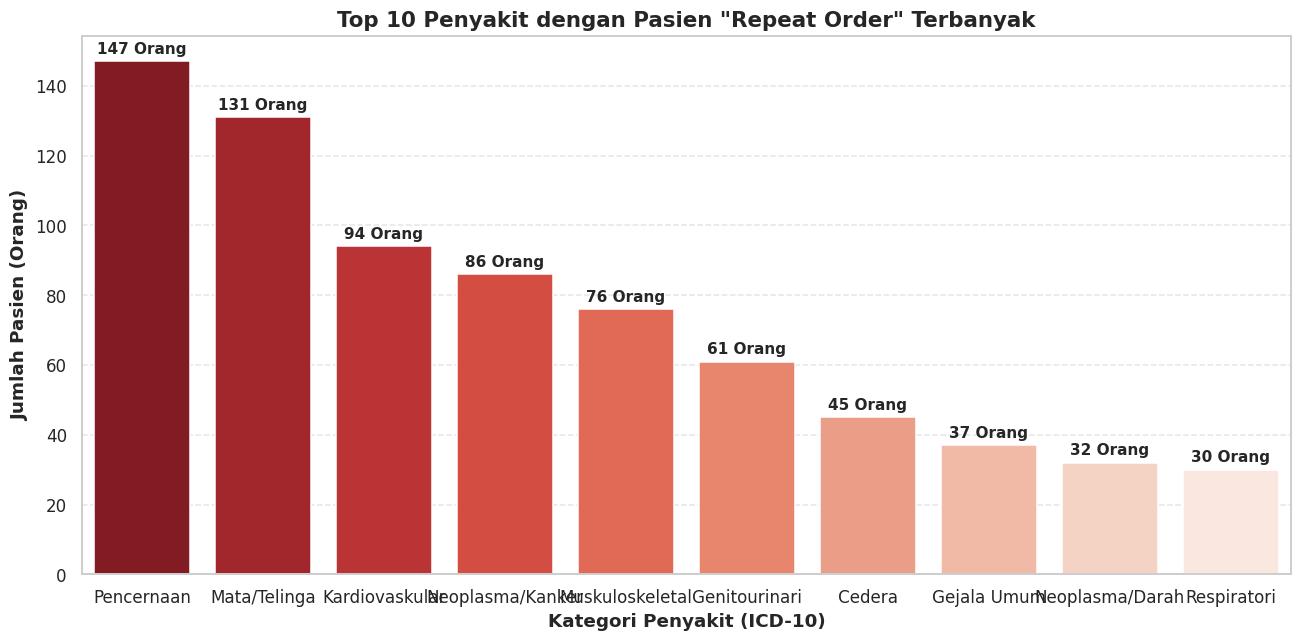

=== Rincian Jumlah Pasien Repeat ===


,ICD_Group,Jumlah_Pasien_Repeat
13,Pencernaan,147
9,Mata/Telinga,131
6,Kardiovaskular,94
12,Neoplasma/Kanker,86
10,Muskuloskeletal,76
4,Genitourinari,61
0,Cedera,45
3,Gejala Umum,37
11,Neoplasma/Darah,32
14,Respiratori,30


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- 1. SIAPKAN DATA ---
# Asumsi 'df' adalah dataframe hasil merge (Klaim + Polis) yang sudah Anda miliki
# Pastikan kolom 'ICD_Group' sudah ada (Huruf pertama Diagnosis)
# Jika belum ada, uncomment baris di bawah:
# df['ICD_Group'] = df['Diagnosis'].astype(str).str[0].str.upper()

# --- 2. HITUNG PASIEN REPEAT ORDER ---
# Langkah A: Hitung berapa kali setiap pasien klaim untuk tiap penyakit
pasien_per_penyakit = df.groupby(['ICD_Group', 'Nomor Polis']).size().reset_index(name='Jumlah_Klaim')

# Langkah B: Filter HANYA pasien yang klaim lebih dari 1x (Repeat)
pasien_repeat = pasien_per_penyakit[pasien_per_penyakit['Jumlah_Klaim'] > 1]

# Langkah C: Hitung total pasien unik yang repeat di setiap penyakit
summary_repeat = pasien_repeat.groupby('ICD_Group')['Nomor Polis'].nunique().reset_index(name='Jumlah_Pasien_Repeat')

# Urutkan dari yang terbanyak
summary_repeat = summary_repeat.sort_values(by='Jumlah_Pasien_Repeat', ascending=False)

# --- 3. VISUALISASI ---
plt.figure(figsize=(12, 6))

# Plot Bar Chart
ax = sns.barplot(
    data=summary_repeat.head(10), # Ambil Top 10 Penyakit
    x='ICD_Group', 
    y='Jumlah_Pasien_Repeat', 
    palette='Reds_r' # Warna merah biar keliatan 'warning' (opsional)
)

# Judul & Label
plt.title('Top 10 Penyakit dengan Pasien "Repeat Order" Terbanyak', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Penyakit (ICD-10)', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Pasien (Orang)', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tampilkan Angka di Atas Batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} Orang', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# --- 4. PRINT TABEL ---
print("=== Rincian Jumlah Pasien Repeat ===")
display(summary_repeat.head(10))

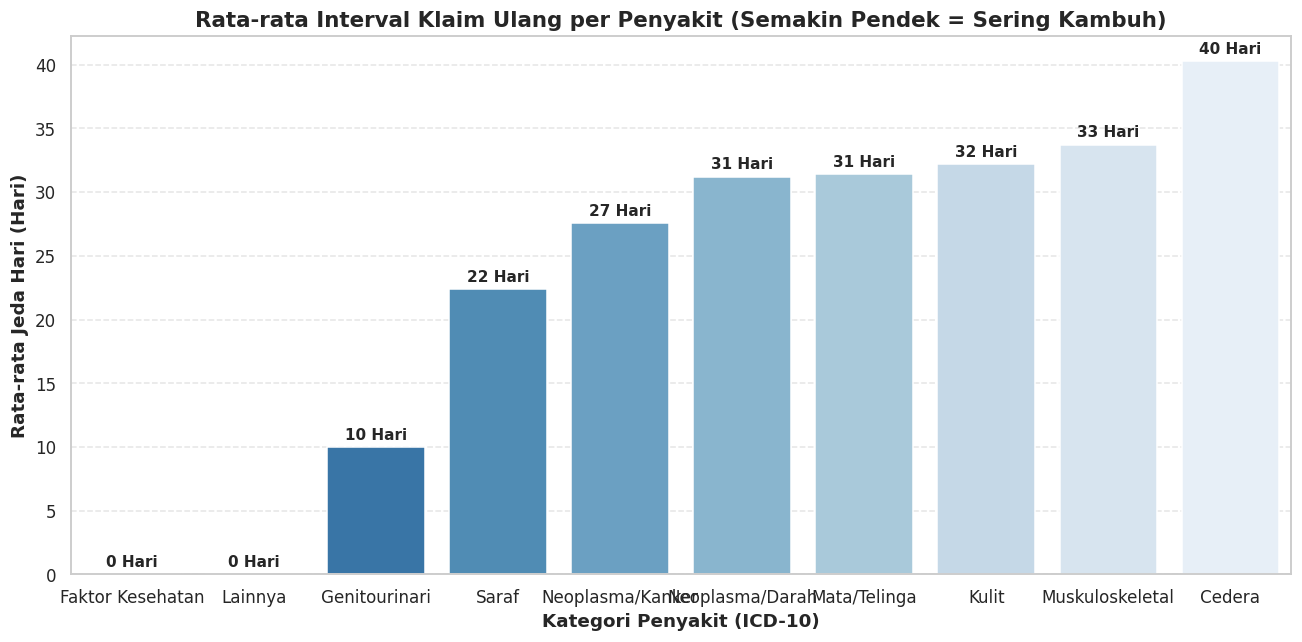

=== Rata-rata Jeda Hari Klaim Ulang ===
(Urutan dari yang paling sering/cepat kambuh)


,ICD_Group,Interval_Hari
2,Faktor Kesehatan,0.000000
8,Lainnya,0.000000
4,Genitourinari,10.003295
15,Saraf,22.400000
12,Neoplasma/Kanker,27.581796
11,Neoplasma/Darah,31.208955
9,Mata/Telinga,31.383954
7,Kulit,32.212121
10,Muskuloskeletal,33.723958
0,Cedera,40.252874


In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. SIAPKAN DATA ---
df['Tgl Kejadian'] = pd.to_datetime(df['Tanggal Pembayaran Klaim']) 

# Urutkan data berdasarkan Pasien, Penyakit, dan Waktu (PENTING!)
df_sorted = df.sort_values(by=['Nomor Polis', 'ICD_Group', 'Tgl Kejadian']).copy()

# --- 2. HITUNG INTERVAL (JEDA HARI) ---
# Ambil tanggal kejadian SEBELUMNYA untuk Pasien yg sama & Penyakit yg sama
df_sorted['Tgl_Sebelumnya'] = df_sorted.groupby(['Nomor Polis', 'ICD_Group'])['Tgl Kejadian'].shift(1)

# Hitung selisih hari
df_sorted['Interval_Hari'] = (df_sorted['Tgl Kejadian'] - df_sorted['Tgl_Sebelumnya']).dt.days

# Hapus baris yg kosong (klaim pertama tidak punya interval)
df_interval = df_sorted.dropna(subset=['Interval_Hari'])

# --- 3. HITUNG RATA-RATA PER PENYAKIT ---
avg_interval = df_interval.groupby('ICD_Group')['Interval_Hari'].mean().reset_index()
avg_interval = avg_interval.sort_values(by='Interval_Hari', ascending=True) # Urut dari yg tercepat kambuh

# --- 4. VISUALISASI ---
plt.figure(figsize=(12, 6))

# Plot Bar Chart
ax = sns.barplot(
    data=avg_interval.head(10), # Top 10 Penyakit dengan Interval Terpendek (Cepat Kambuh)
    x='ICD_Group', 
    y='Interval_Hari', 
    palette='Blues_r' 
)

# Judul & Label
plt.title('Rata-rata Interval Klaim Ulang per Penyakit (Semakin Pendek = Sering Kambuh)', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Penyakit (ICD-10)', fontsize=12, fontweight='bold')
plt.ylabel('Rata-rata Jeda Hari (Hari)', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tampilkan Angka di Atas Batang
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())} Hari', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# --- 5. TAMPILKAN DATA ---
print("=== Rata-rata Jeda Hari Klaim Ulang ===")
print("(Urutan dari yang paling sering/cepat kambuh)")
display(avg_interval.head(10))

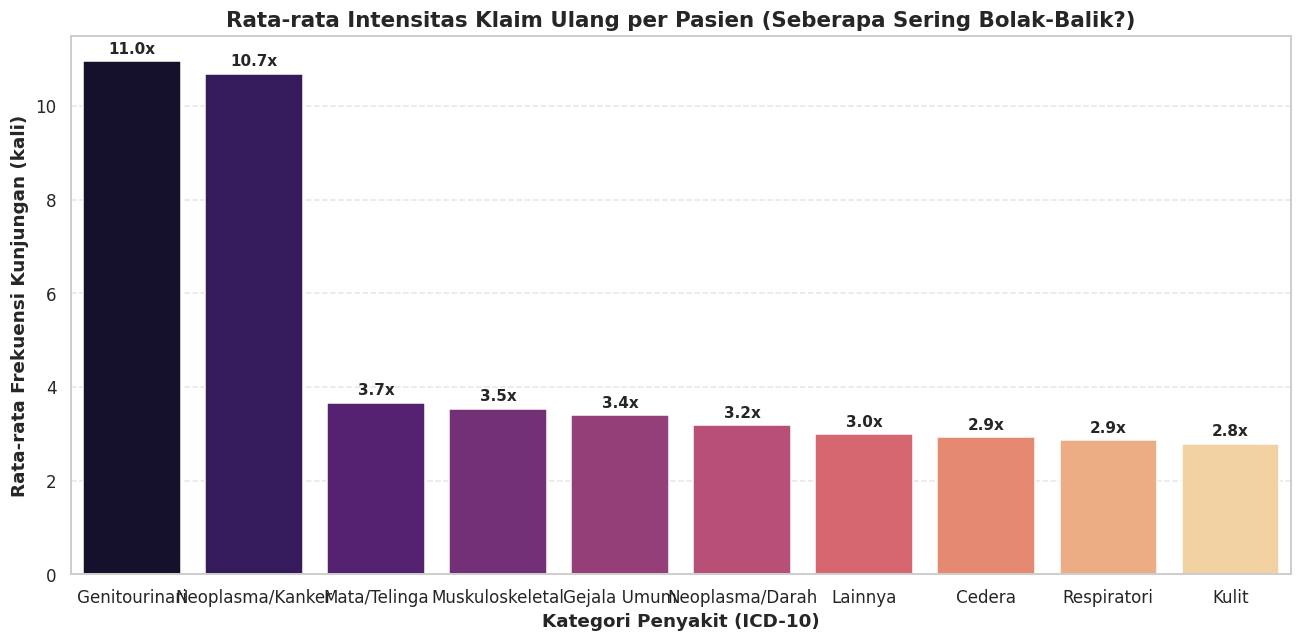

=== Tabel Rata-rata Frekuensi Klaim Ulang ===
(Hanya menghitung pasien yang datang > 1 kali)


,ICD_Group,Rata2_Frekuensi
4,Genitourinari,10.950820
12,Neoplasma/Kanker,10.686047
9,Mata/Telinga,3.664122
10,Muskuloskeletal,3.539474
3,Gejala Umum,3.405405
11,Neoplasma/Darah,3.187500
8,Lainnya,3.000000
0,Cedera,2.933333
14,Respiratori,2.866667
7,Kulit,2.789474


In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. SIAPKAN DATA ---
# Pastikan 'df' sudah ada (dari langkah sebelumnya)
# df = pd.merge(df_klaim, df_polis, on='Nomor Polis', how='left')
# df['ICD_Group'] = df['Diagnosis'].astype(str).str[0].str.upper()

# --- 2. HITUNG FREKUENSI KLAIM ---
# Hitung berapa kali setiap pasien klaim untuk penyakit tertentu
klaim_per_pasien = df.groupby(['ICD_Group', 'Nomor Polis']).size().reset_index(name='Jumlah_Klaim')

# Filter HANYA yang > 1 kali (karena kita bicara "Klaim Ulang")
# Jika kita masukkan yang 1x, rata-ratanya akan bias ke angka 1.
pasien_repeat = klaim_per_pasien[klaim_per_pasien['Jumlah_Klaim'] > 1]

# Hitung Rata-rata Frekuensi untuk mereka yang Repeat
avg_repeat_freq = pasien_repeat.groupby('ICD_Group')['Jumlah_Klaim'].mean().reset_index()
avg_repeat_freq.columns = ['ICD_Group', 'Rata2_Frekuensi']

# Urutkan dari yang paling sering bolak-balik
avg_repeat_freq = avg_repeat_freq.sort_values(by='Rata2_Frekuensi', ascending=False)

# --- 3. VISUALISASI ---
plt.figure(figsize=(12, 6))

# Plot Bar Chart
ax = sns.barplot(
    data=avg_repeat_freq.head(10), # Top 10 Penyakit Paling Kronis
    x='ICD_Group', 
    y='Rata2_Frekuensi', 
    palette='magma' # Warna gelap untuk intensitas tinggi
)

# Judul & Label
plt.title('Rata-rata Intensitas Klaim Ulang per Pasien (Seberapa Sering Bolak-Balik?)', fontsize=14, fontweight='bold')
plt.xlabel('Kategori Penyakit (ICD-10)', fontsize=12, fontweight='bold')
plt.ylabel('Rata-rata Frekuensi Kunjungan (kali)', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Tampilkan Angka di Atas Batang
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}x', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 8), 
                textcoords='offset points',
                fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# --- 4. DATA TABLE ---
print("=== Tabel Rata-rata Frekuensi Klaim Ulang ===")
print("(Hanya menghitung pasien yang datang > 1 kali)")
display(avg_repeat_freq.head(10))

### 4.5 Korelasi: Beban Klaim vs Kecepatan Pemrosesan

Apakah peningkatan volume klaim mempengaruhi kecepatan pemrosesan? Dual-axis chart berikut menunjukkan hubungan antara jumlah klaim dan processing time.

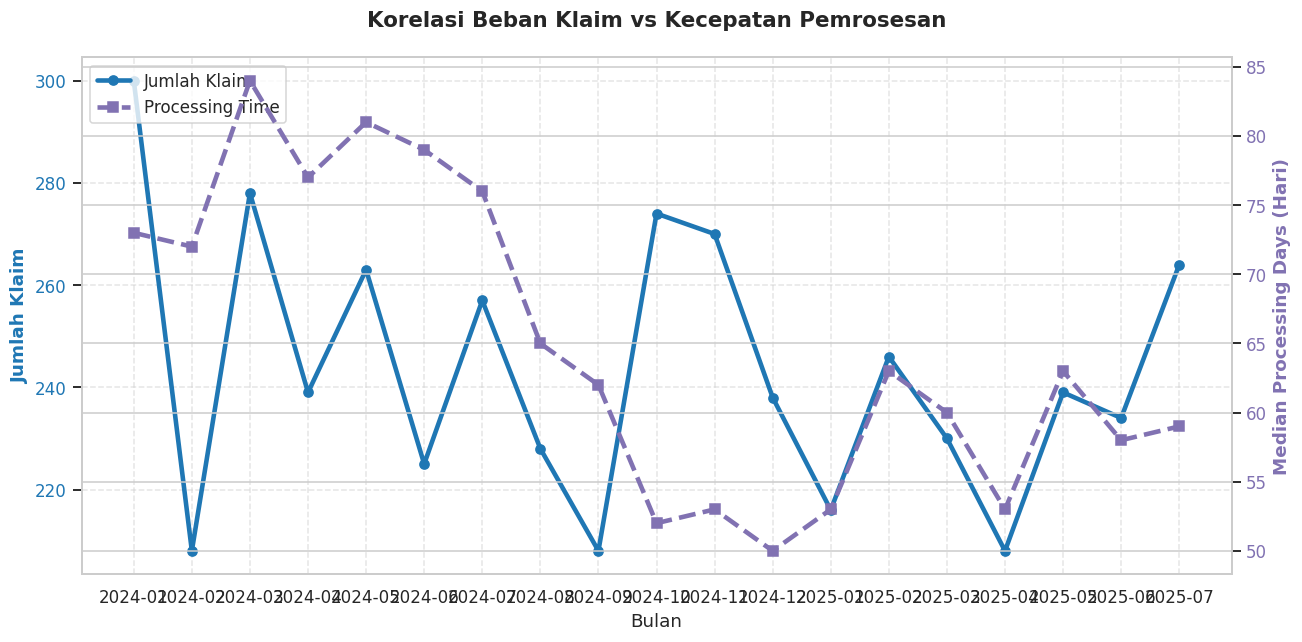

In [ ]:
# Siapkan Data Agregat Total
total_claim_trend = trend_lok.groupby('Bulan')['Jumlah'].sum().reset_index()
proc_trend = proc.groupby('Bulan')['Processing_Days'].median().reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot 1: Jumlah Klaim (Sumbu Y Kiri)
color_claim = '#1f77b4'
ax1.set_xlabel('Bulan')
ax1.set_ylabel('Jumlah Klaim', color=color_claim, fontsize=12, fontweight='bold')
line1 = ax1.plot(total_claim_trend['Bulan'], total_claim_trend['Jumlah'], 
                 marker='o', color=color_claim, linewidth=3, label='Jumlah Klaim')
ax1.tick_params(axis='y', labelcolor=color_claim)
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot 2: Processing Time (Sumbu Y Kanan)
ax2 = ax1.twinx()
color_proc = '#8172B2'
ax2.set_ylabel('Median Processing Days (Hari)', color=color_proc, fontsize=12, fontweight='bold')
line2 = ax2.plot(proc_trend['Bulan'], proc_trend['Processing_Days'], 
                 marker='s', color=color_proc, linewidth=3, linestyle='--', label='Processing Time')
ax2.tick_params(axis='y', labelcolor=color_proc)

plt.title('Korelasi Beban Klaim vs Kecepatan Pemrosesan', fontsize=14, fontweight='bold', pad=20)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== Detail Jumlah Klaim Awal 2024 ===
   Tanggal  Jumlah
2024-01-01     300
2024-02-01     208
2024-03-01     278
2024-04-01     239

> Rata-rata Klaim (Jan-Apr 2024): 256 klaim/bulan


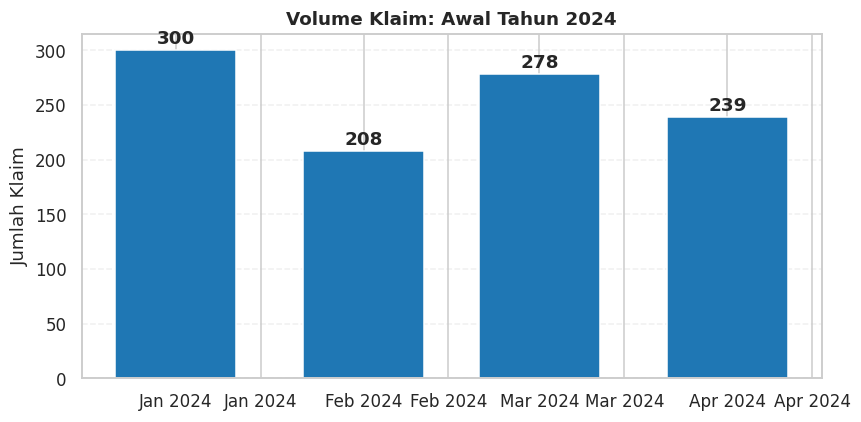

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# 1. Pastikan format datetime aman
total_claim_trend['Bulan'] = pd.to_datetime(total_claim_trend['Bulan'])

# 2. Filter khusus periode Awal 2024 (Januari - April)
start_date = '2024-01-01'
end_date = '2024-04-30'

check_awal_2024 = total_claim_trend[
    (total_claim_trend['Bulan'] >= start_date) & 
    (total_claim_trend['Bulan'] <= end_date)
].sort_values('Bulan')

# 3. Tampilkan Data Tabel
print("=== Detail Jumlah Klaim Awal 2024 ===")
# Format tanggal agar enak dibaca (Tahun-Bulan-Hari)
check_awal_2024['Tanggal'] = check_awal_2024['Bulan'].dt.strftime('%Y-%m-%d')
print(check_awal_2024[['Tanggal', 'Jumlah']].to_string(index=False))

# Hitung Rata-rata periode ini
avg_claim = check_awal_2024['Jumlah'].mean()
print(f"\n> Rata-rata Klaim (Jan-Apr 2024): {avg_claim:.0f} klaim/bulan")

# 4. Visualisasi Fokus Bar Chart
plt.figure(figsize=(8, 4))
bars = plt.bar(check_awal_2024['Bulan'], check_awal_2024['Jumlah'], 
               color='#1f77b4', width=20) # width 20 agar bar tidak terlalu tipis

# Tambahkan label angka di atas batang
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, int(yval), 
             ha='center', va='bottom', fontweight='bold')

plt.title('Volume Klaim: Awal Tahun 2024', fontsize=12, fontweight='bold')
plt.ylabel('Jumlah Klaim')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y')) # Format Bulan Tahun
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Pastikan data sudah diagregasi per bulan
# total_claim_trend -> Kolom: 'Bulan', 'Jumlah'
# proc_trend -> Kolom: 'Bulan', 'Processing_Days'

# 1. Gabungkan Data dulu biar aman (Inner Join on Bulan)
df_gabung = pd.merge(total_claim_trend, proc_trend, on='Bulan')
df_gabung['Bulan'] = pd.to_datetime(df_gabung['Bulan'])

# 2. Rumus Normalisasi Min-Max
# Rumus: (Nilai - Min) / (Max - Min)
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

df_gabung['Norm_Claim'] = normalize(df_gabung['Jumlah'])
df_gabung['Norm_Time'] = normalize(df_gabung['Processing_Days'])

# 3. Visualisasi Apple to Apple
fig, ax = plt.subplots(figsize=(12, 6))

# Plot Garis Ternormalisasi
plt.plot(df_gabung['Bulan'], df_gabung['Norm_Claim'], 
         marker='o', label='Volume Klaim (Skala 0-1)', linewidth=3, color='#1f77b4')

plt.plot(df_gabung['Bulan'], df_gabung['Norm_Time'], 
         marker='s', label='Lama Proses (Skala 0-1)', linewidth=3, color='#d62728', linestyle='--')

# Area Interpretasi
plt.title('Analisis Beban Kerja: Apakah Volume Tinggi Bikin Lambat?', fontsize=14, fontweight='bold')
plt.ylabel('Skala Intensitas (0=Min, 1=Max)', fontsize=12)
plt.xlabel('Bulan')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# Format Tanggal
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 4. Cek Korelasi Statistik (Angka Pasti)
korelasi = df_gabung['Jumlah'].corr(df_gabung['Processing_Days'])
print(f"Koefisien Korelasi Pearson: {korelasi:.2f}")

ValueError: You are trying to merge on datetime64[us] and str columns for key 'Bulan'. If you wish to proceed you should use pd.concat

**Insight Korelasi Volume vs Processing:**
- Chart ini menunjukkan apakah ada **hubungan terbalik** antara volume klaim dan kecepatan pemrosesan
- Jika processing time meningkat saat volume tinggi, ini mengindikasikan **bottleneck kapasitas** pada tim klaim
- Sebaliknya, jika keduanya tidak berkorelasi, berarti tim klaim sudah **scalable** atau ada faktor lain yang mempengaruhi processing time
- Insight ini krusial untuk **resource planning** dan **hiring decisions**

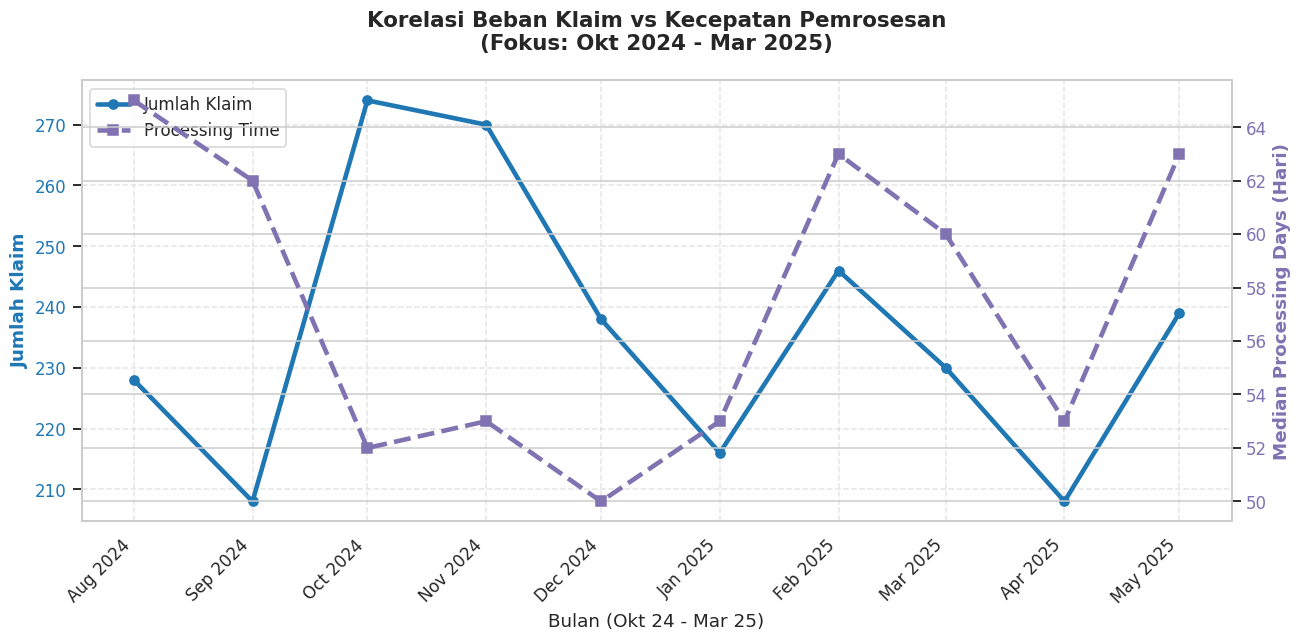

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# --- 1. Pastikan Format Tanggal Benar ---
# Konversi kolom 'Bulan' ke datetime object agar bisa difilter
total_claim_trend['Bulan'] = pd.to_datetime(total_claim_trend['Bulan'])
proc_trend['Bulan'] = pd.to_datetime(proc_trend['Bulan'])

# --- 2. Filter Data (Oktober 2024 - Maret 2025) ---
start_date = '2024-8-01'
end_date = '2025-05-31'

# Filter data klaim
sub_claim = total_claim_trend[
    (total_claim_trend['Bulan'] >= start_date) & 
    (total_claim_trend['Bulan'] <= end_date)
]

# Filter data processing time
sub_proc = proc_trend[
    (proc_trend['Bulan'] >= start_date) & 
    (proc_trend['Bulan'] <= end_date)
]

# --- 3. Plotting ---
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot 1: Jumlah Klaim (Sumbu Y Kiri) - Menggunakan data 'sub_claim'
color_claim = '#1f77b4'
line1 = ax1.plot(sub_claim['Bulan'], sub_claim['Jumlah'], 
                 marker='o', color=color_claim, linewidth=3, label='Jumlah Klaim')

ax1.set_xlabel('Bulan (Okt 24 - Mar 25)')
ax1.set_ylabel('Jumlah Klaim', color=color_claim, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=color_claim)
ax1.grid(True, linestyle='--', alpha=0.5)

# Plot 2: Processing Time (Sumbu Y Kanan) - Menggunakan data 'sub_proc'
ax2 = ax1.twinx()
color_proc = '#8172B2'
line2 = ax2.plot(sub_proc['Bulan'], sub_proc['Processing_Days'], 
                 marker='s', color=color_proc, linewidth=3, linestyle='--', label='Processing Time')

ax2.set_ylabel('Median Processing Days (Hari)', color=color_proc, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=color_proc)

# --- 4. Finishing Touches ---
plt.title('Korelasi Beban Klaim vs Kecepatan Pemrosesan\n(Fokus: Okt 2024 - Mar 2025)', 
          fontsize=14, fontweight='bold', pad=20)

# Menggabungkan Legend
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

# Format Sumbu X agar lebih rapi (Bulan-Tahun)
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator()) # Pastikan setiap bulan muncul
plt.setp(ax1.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

### 4.6 Korelasi: Total Nominal vs Processing Time

Apakah klaim dengan total nominal lebih besar memerlukan waktu pemrosesan lebih lama?

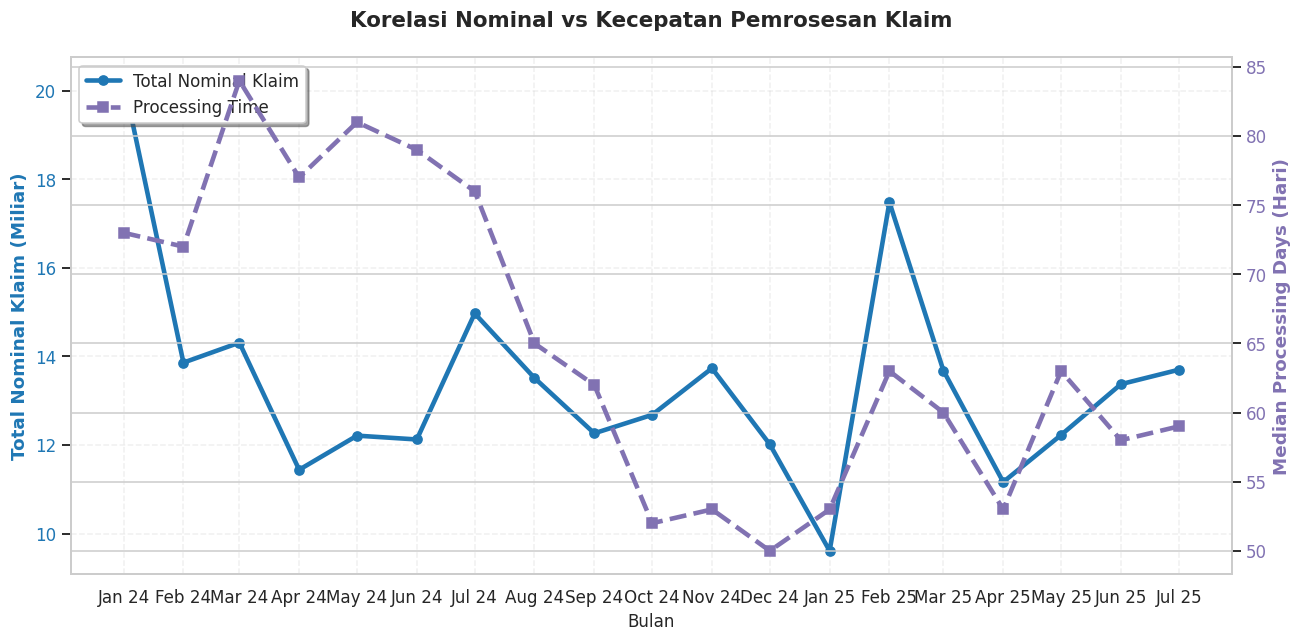

In [ ]:
nominal_trend = trend_lok.groupby('Bulan')['Total'].sum().reset_index()
nominal_trend['Bulan'] = pd.to_datetime(nominal_trend['Bulan'])
proc_trend_dt = proc.groupby('Bulan')['Processing_Days'].median().reset_index()
proc_trend_dt['Bulan'] = pd.to_datetime(proc_trend_dt['Bulan'])

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot 1: Total Nominal Klaim (Sumbu Y Kiri)
color_nominal = '#1f77b4' 
ax1.set_xlabel('Bulan', fontsize=11)
ax1.set_ylabel('Total Nominal Klaim (Miliar)', color=color_nominal, fontsize=12, fontweight='bold')
line1 = ax1.plot(nominal_trend['Bulan'], nominal_trend['Total']/1e9, 
                 marker='o', color=color_nominal, linewidth=3, label='Total Nominal Klaim')
ax1.tick_params(axis='y', labelcolor=color_nominal)
ax1.grid(True, linestyle='--', alpha=0.3)

# Plot 2: Processing Time (Sumbu Y Kanan)
ax2 = ax1.twinx() 
color_proc = '#8172B2' 
ax2.set_ylabel('Median Processing Days (Hari)', color=color_proc, fontsize=12, fontweight='bold')
line2 = ax2.plot(proc_trend_dt['Bulan'], proc_trend_dt['Processing_Days'], 
                 marker='s', color=color_proc, linewidth=3, linestyle='--', label='Processing Time')
ax2.tick_params(axis='y', labelcolor=color_proc)

# Formatting Sumbu X
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator())

plt.title('Korelasi Nominal vs Kecepatan Pemrosesan Klaim', fontsize=14, fontweight='bold', pad=20)

lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', frameon=True, shadow=True)

fig.autofmt_xdate(rotation=0, ha='center') 

plt.tight_layout()
plt.show()

**Insight Nominal vs Processing Time:**
- Grafik ini melengkapi analisis sebelumnya dengan melihat dari **sisi nilai** (bukan volume)
- Bulan-bulan dengan **lonjakan nominal** (misalnya karena klaim besar dari Singapore) mungkin menunjukkan **peningkatan processing time** karena klaim besar cenderung memerlukan review lebih mendalam
- **Format tanggal** yang jelas (Jan 24, Feb 24, dst) memudahkan identifikasi bulan-bulan kritis

---

## Fase 5: Analisis Diagnosis (ICD)

### 5.1 Top Diagnosis per Lokasi RS

Perbandingan diagnosis terbanyak di tiga lokasi RS utama menunjukkan **pola referral** dan **spesialisasi** masing-masing lokasi.

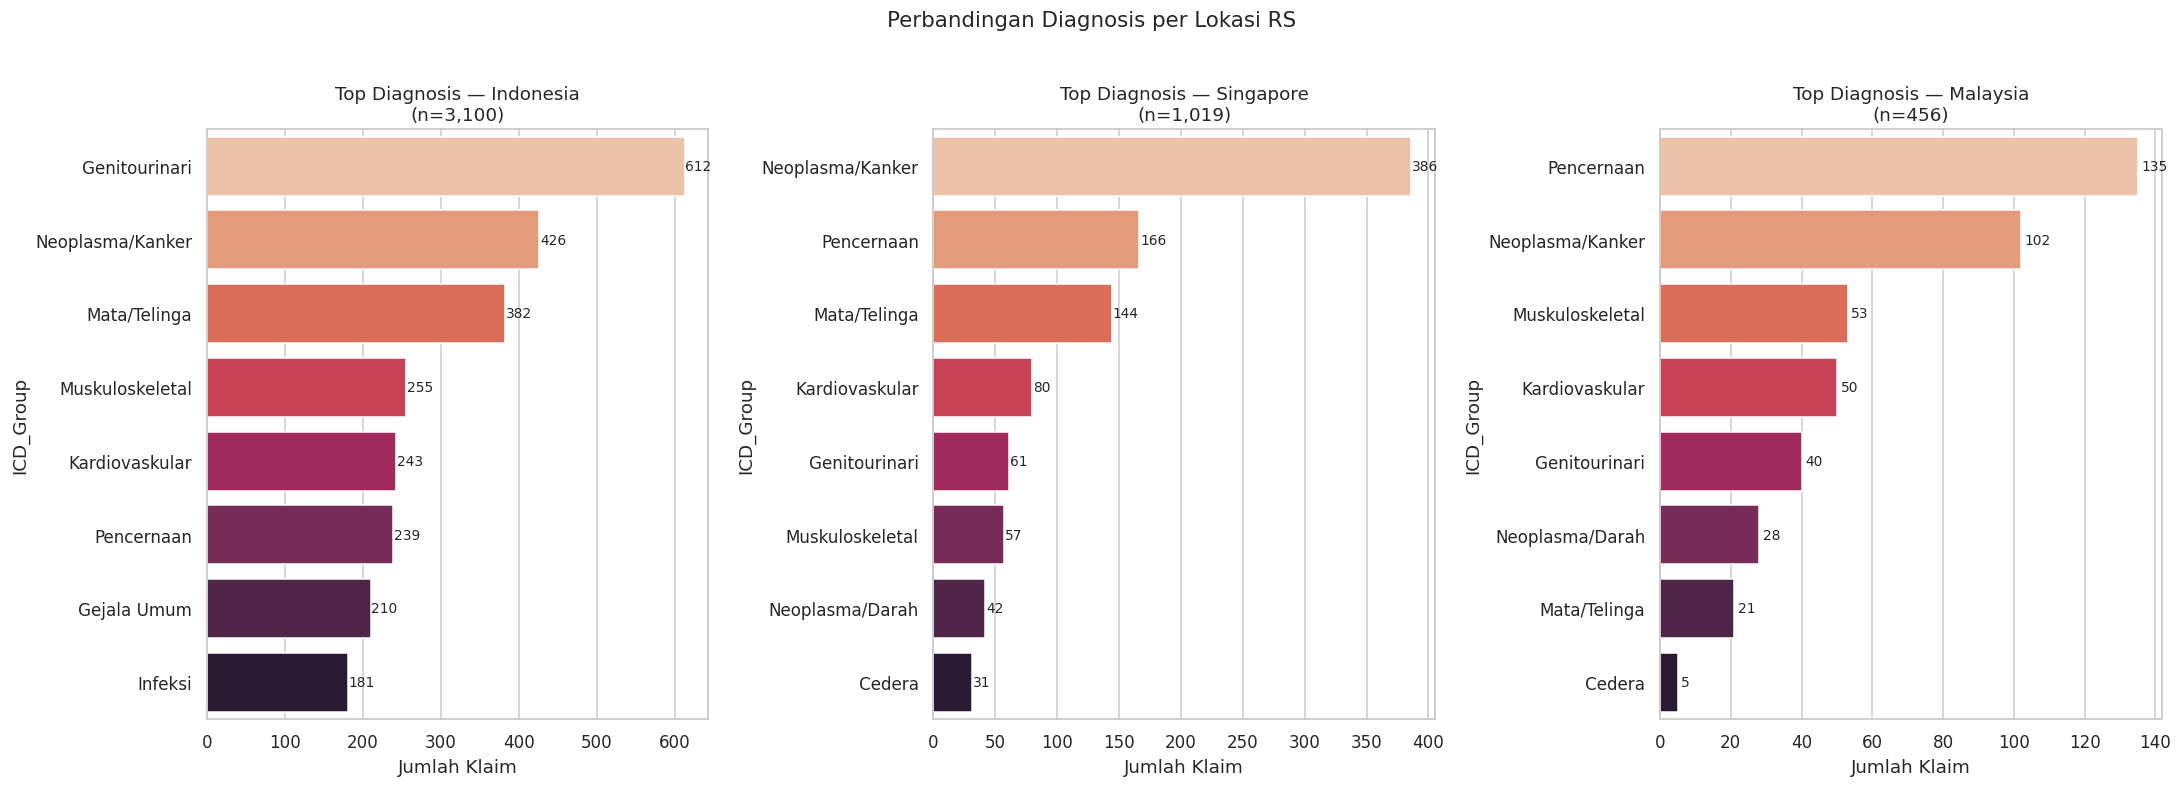

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for ax, lokasi in zip(axes, ['Indonesia', 'Singapore', 'Malaysia']):
    data = df[df['Lokasi RS'] == lokasi]
    top_icd = data['ICD_Group'].value_counts().head(8)
    sns.barplot(y=top_icd.index, x=top_icd.values, ax=ax, palette='rocket_r')
    ax.set_title(f'Top Diagnosis — {lokasi}\n(n={len(data):,})')
    ax.set_xlabel('Jumlah Klaim')
    for bar, val in zip(ax.patches, top_icd.values):
        ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                f'{val}', va='center', fontsize=9)

plt.suptitle('Perbandingan Diagnosis per Lokasi RS', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Insight Diagnosis per Lokasi:**

- **Indonesia**: Profil diagnosis lebih **beragam** dan mencerminkan populasi umum — mencakup Kardiovaskular, Muskuloskeletal, Pencernaan, dll. Ini sesuai karena Indonesia menangani majority of routine cases

- **Singapore**: **Neoplasma/Kanker mendominasi** — mengkonfirmasi bahwa Singapore digunakan sebagai destinasi utama untuk perawatan kanker. Ini logis karena Singapore memiliki pusat onkologi berkelas internasional (seperti NCIS, Parkway Cancer Centre)

- **Malaysia**: Profil diagnosis **campuran** antara kasus umum dan spesifik — bisa jadi Malaysia digunakan untuk kasus yang lebih murah dari Singapore tapi memerlukan teknologi/expertise yang belum tersedia di Indonesia

- **Implikasi**: Pola ini mendukung strategi **tiered referral** — kasus ringan/moderate di Indonesia, kasus berat/spesifik di Singapore/Malaysia

### 5.2 Distribusi Diagnosis per Plan Code

Apakah jenis plan mempengaruhi profil penyakit yang diklaim?

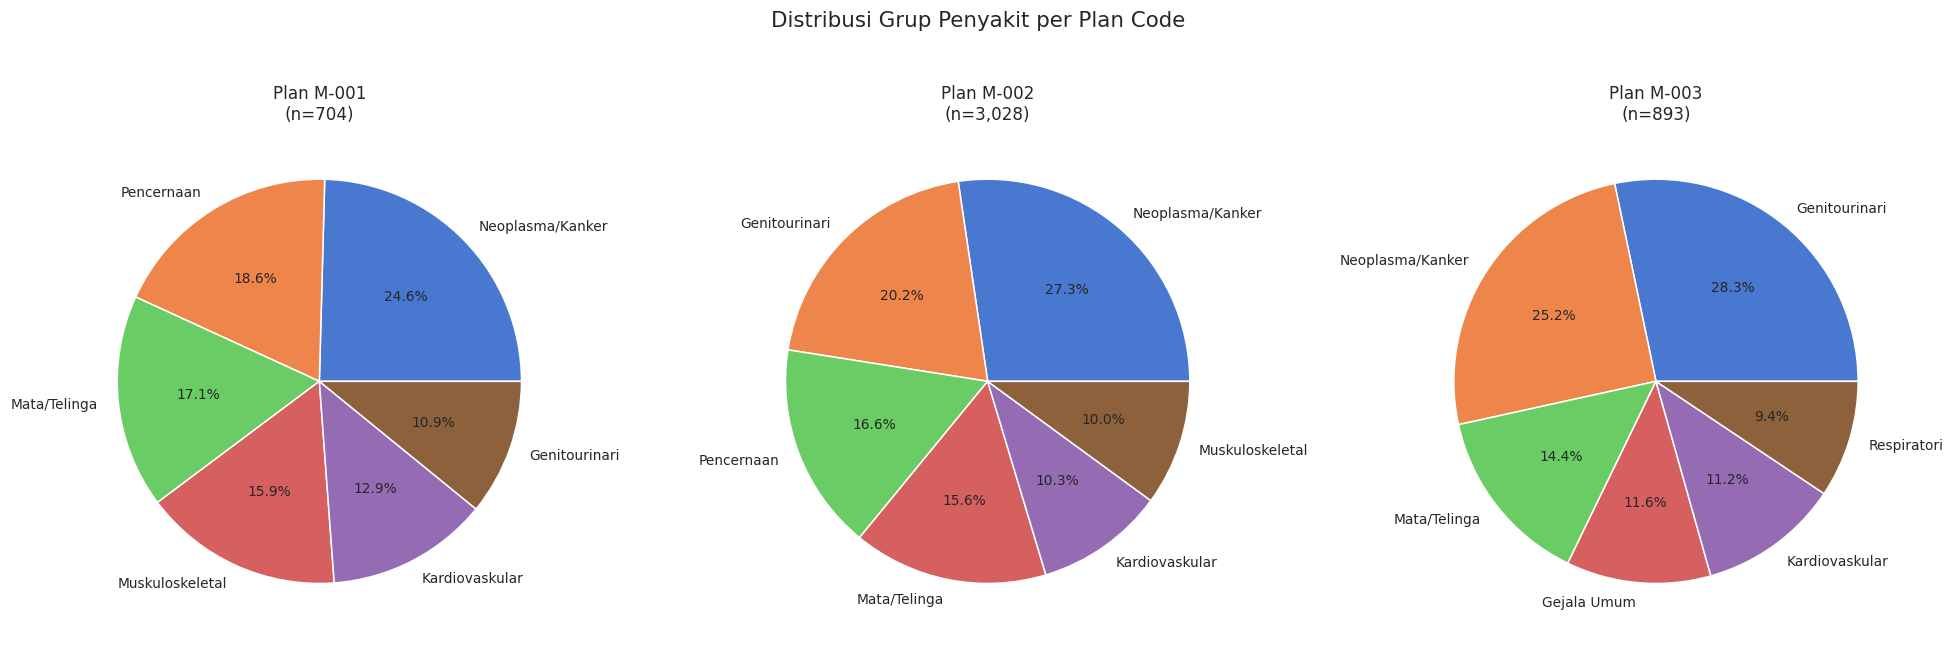

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, plan in zip(axes, ['M-001', 'M-002', 'M-003']):
    data = df[df['Plan Code'] == plan]
    top = data['ICD_Group'].value_counts().head(6)
    ax.pie(top, labels=top.index, autopct='%1.1f%%', textprops={'fontsize': 9})
    ax.set_title(f'Plan {plan}\n(n={len(data):,})', fontsize=11)

plt.suptitle('Distribusi Grup Penyakit per Plan Code', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Insight Diagnosis per Plan:**
- Setiap plan menunjukkan **profil diagnosis yang sedikit berbeda**, yang mungkin mencerminkan:
  - Perbedaan **demografi nasabah** per plan (usia, risiko pekerjaan)
  - Perbedaan **coverage** yang mempengaruhi jenis perawatan yang diklaim
  - **Adverse selection** — nasabah dengan risiko tinggi memilih plan dengan benefit lebih besar

### 5.3 Distribusi Keseluruhan & Cost Driver Analysis

Analisis menyeluruh yang membandingkan **proporsi volume klaim** (pie chart) vs **proporsi biaya** (cost driver bar) per grup penyakit.

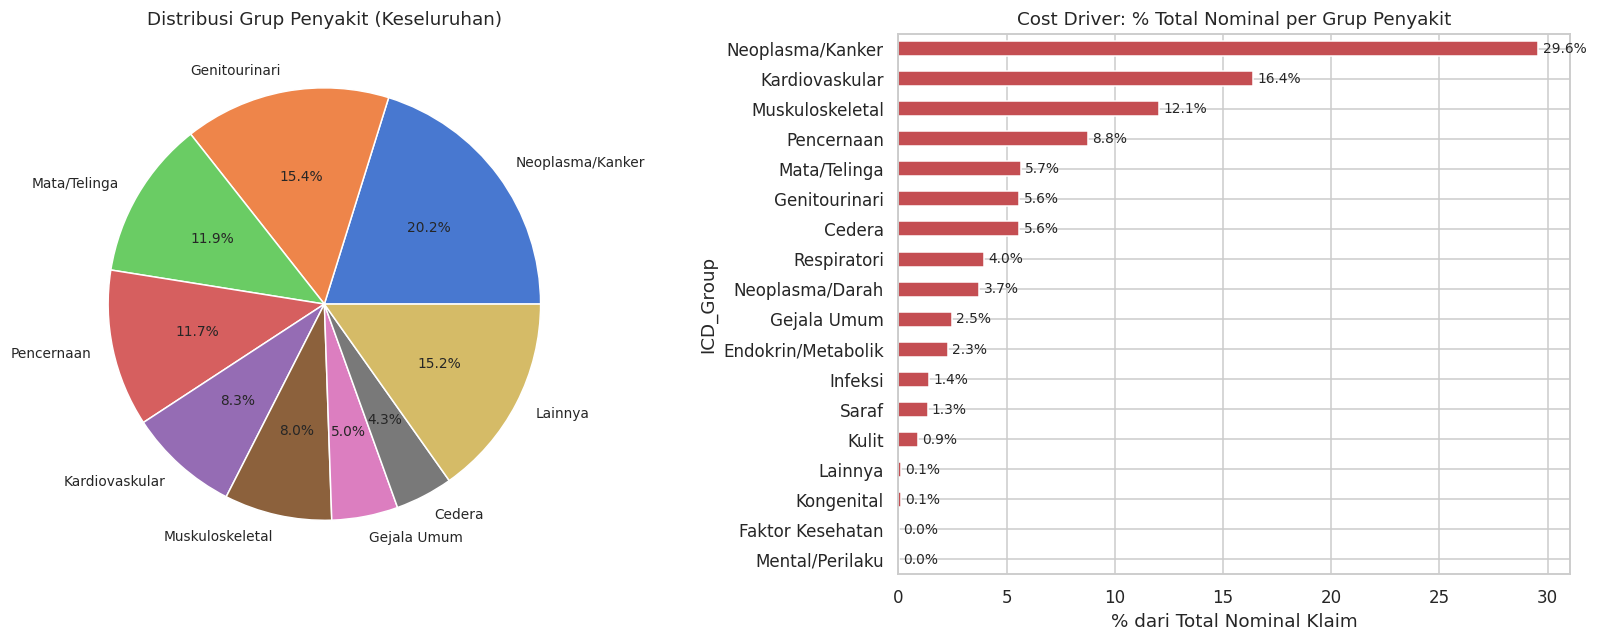

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Pie chart overall
icd_overall = df['ICD_Group'].value_counts()
top_n = 8
other = icd_overall[top_n:].sum()
icd_pie = pd.concat([icd_overall[:top_n], pd.Series({'Lainnya': other})])
axes[0].pie(icd_pie, labels=icd_pie.index, autopct='%1.1f%%', textprops={'fontsize': 9})
axes[0].set_title('Distribusi Grup Penyakit (Keseluruhan)')

# Cost driver: total nominal per ICD group as % of total
cost_driver = df.groupby('ICD_Group')['Nominal Klaim Yang Disetujui'].sum().sort_values(ascending=True)
cost_pct = (cost_driver / cost_driver.sum() * 100)
cost_pct.plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('Cost Driver: % Total Nominal per Grup Penyakit')
axes[1].set_xlabel('% dari Total Nominal Klaim')
for bar, val in zip(axes[1].patches, cost_pct.values):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

**Insight Cost Driver — Temuan Strategis:**

Perbandingan **volume vs cost** mengungkap informasi krusial:

- **Neoplasma/Kanker**: Grup ini mungkin menyumbang ~20% dari jumlah klaim tetapi bisa mencapai **30-40% dari total nominal**. Ini menjadikannya **cost driver #1 yang tidak proporsional**

- **Kardiovaskular & Muskuloskeletal**: Grup dengan volume tinggi yang juga menyumbang proporsi biaya signifikan — perlu perhatian dari sisi **prevalensi populasi**

- **Grup dengan cost-per-claim tinggi** (seperti Kongenital, Neoplasma) memerlukan **case management individual** karena setiap klaim berpotensi sangat mahal

- **Implikasi pricing**: Aktuaris perlu mempertimbangkan **distribusi diagnosis** dalam penetapan premi, bukan hanya rata-rata klaim keseluruhan

---

## Fase 6: Analisis Anomali & Outlier

### 6.1 Deteksi Outlier Nominal Klaim (Metode IQR)

Menggunakan metode Interquartile Range (IQR) untuk mengidentifikasi klaim dengan nominal di luar batas wajar.

In [ ]:
Q1 = df['Nominal Klaim Yang Disetujui'].quantile(0.25)
Q3 = df['Nominal Klaim Yang Disetujui'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['Nominal Klaim Yang Disetujui'] < lower) | (df['Nominal Klaim Yang Disetujui'] > upper)]

print(f'IQR Method:')
print(f'  Q1     : Rp {Q1:,.0f}')
print(f'  Q3     : Rp {Q3:,.0f}')
print(f'  IQR    : Rp {IQR:,.0f}')
print(f'  Lower  : Rp {lower:,.0f}')
print(f'  Upper  : Rp {upper:,.0f}')
print(f'\n  Jumlah outlier: {len(outliers):,} ({len(outliers)/len(df)*100:.1f}%)')
print(f'  Total nominal outlier: Rp {outliers["Nominal Klaim Yang Disetujui"].sum()/1e9:.1f} Miliar')
print(f'  vs Total keseluruhan : Rp {df["Nominal Klaim Yang Disetujui"].sum()/1e9:.1f} Miliar')
print(f'  => Outlier = {outliers["Nominal Klaim Yang Disetujui"].sum()/df["Nominal Klaim Yang Disetujui"].sum()*100:.1f}% dari total nominal')

# Breakdown outlier per ICD Group
print(f'\nOutlier per Grup Penyakit:')
print(outliers['ICD_Group'].value_counts().to_string())

IQR Method:
  Q1     : Rp 2,275,384
  Q3     : Rp 51,115,437
  IQR    : Rp 48,840,053
  Lower  : Rp -70,984,696
  Upper  : Rp 124,375,517

  Jumlah outlier: 507 (11.0%)
  Total nominal outlier: Rp 160.8 Miliar
  vs Total keseluruhan : Rp 254.6 Miliar
  => Outlier = 63.2% dari total nominal

Outlier per Grup Penyakit:
ICD_Group
Neoplasma/Kanker      162
Kardiovaskular         96
Muskuloskeletal        78
Cedera                 34
Pencernaan             33
Mata/Telinga           24
Genitourinari          23
Neoplasma/Darah        18
Respiratori            15
Endokrin/Metabolik      8
Saraf                   6
Gejala Umum             5
Kulit                   3
Kongenital              1
Infeksi                 1


**Insight Outlier — Temuan Kritis:**

| Metrik | Nilai |
|:---:|:---:|
| Q1 (25th percentile) | Rp 2.275.384 |
| Q3 (75th percentile) | Rp 51.115.437 |
| IQR | Rp 48.840.053 |
| Upper Bound | Rp 124.375.517 |
| **Jumlah Outlier** | **507 (11,0%)** |
| **Total Nominal Outlier** | **Rp 160,8 Miliar** |
| **% dari Total Nominal** | **63,2%** |

**Fakta mengejutkan: 11% klaim menyumbang 63,2% total nominal!**

**Breakdown Outlier per Grup Penyakit:**

| Grup Penyakit | Jumlah Outlier | Insight |
|:---:|:---:|:---:|
| Neoplasma/Kanker | 162 | **#1 — konsisten sebagai cost driver utama** |
| Kardiovaskular | 96 | Penyakit jantung = biaya prosedur tinggi |
| Muskuloskeletal | 78 | Operasi ortopedi mahal |
| Cedera | 34 | Trauma/kecelakaan bisa sangat mahal |
| Pencernaan | 33 | Operasi GI tract |
| Mata/Telinga | 24 | Operasi katarak, cochlear implant |
| Genitourinari | 23 | Prosedur urologi/nefrologi |

**Implikasi:**
- **Konsentrasi biaya** pada segelintir klaim besar memerlukan **reinsurance** yang memadai
- **Case management proaktif** untuk kasus kanker dan kardiovaskular bisa menghemat biaya signifikan
- **Stop-loss insurance** perlu dievaluasi untuk melindungi dari klaim katastrofik

### 6.2 Anomali Data Quality

Dua jenis anomali data yang ditemukan:

#### A. Inpatient dengan LOS = 0 hari (762 record = 16,5%)

Sebanyak **762 klaim** tercatat sebagai Inpatient namun memiliki Length of Stay = 0 hari (tanggal masuk = tanggal keluar). Kemungkinan penyebab:
- **Same-day admission/discharge**: Pasien masuk dan keluar di hari yang sama (misalnya observasi singkat, prosedur minor)
- **Data entry**: Tanggal keluar belum diupdate atau salah input
- **Misklasifikasi**: Seharusnya dikategorikan sebagai One Day Care (ODC) atau Outpatient (OP)

Dengan proporsi **16,5% dari total klaim**, ini merupakan isu data quality yang signifikan dan perlu standarisasi definisi operasional antara "Inpatient" vs "One Day Care".

#### B. Potential Duplicate Claims (16 record)

Ditemukan **16 record** yang memiliki kombinasi identik pada:
- Nomor Polis
- Tanggal Pasien Masuk RS
- Nominal Klaim Yang Disetujui

Beberapa contoh duplikat:

| Pair | Polis | Tanggal | Nominal | ICD | Lokasi | Catatan |
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|
| C-1756-M / C-1758-M | POL-0158 | 2024-05-28 | 17.145.200 | T18.4 | Malaysia | Kemungkinan legitimate (klaim terpisah untuk prosedur berbeda) |
| C-0083-M / C-0085-M | POL-2125 | 2024-06-21 | 0 | H25.9 | Indonesia | Dua klaim Rp 0 — perlu investigasi |
| C-2690-M / C-2692-M | POL-0935 | 2024-07-22 | 2.500.000 | I84.1/K62.1 | Singapore | ICD berbeda tapi nominal sama — mungkin legitimate |

**Catatan**: Tidak semua duplikat berarti fraud — beberapa bisa jadi klaim terpisah untuk diagnosis/prosedur yang berbeda dalam satu kali kunjungan RS. Namun tetap perlu **validasi** manual untuk memastikan tidak ada double-payment.

---

## Analisis Relasional & Cross-Cutting Insights

Bagian ini menyintesis temuan dari seluruh fase analisis untuk mengungkap **hubungan antar variabel** dan **pola tersembunyi** yang tidak terlihat dari analisis individual.

### 1. Relasi Usia → Diagnosis → Lokasi → Nominal

Terdapat **rantai kausalitas** yang jelas:

```
Usia 60+ → Risiko kanker/kardiovaskular ↑ → Perawatan di Singapore → Nominal sangat tinggi
```

- Kelompok **60+** menyumbang 46,2% klaim dan 60,3% nominal
- Diagnosis utama di kelompok ini: **Neoplasma/Kanker** dan **Kardiovaskular**
- Kasus berat cenderung di-refer ke **Singapore** yang biayanya 3-5x Indonesia
- Hasilnya: konsentrasi biaya pada **segmen usia tua + diagnosis berat + lokasi luar negeri**

### 2. Pola Chronic Disease & Repeat Claimers

Dua pola utama repeat claimers:

| Pattern | Diagnose | Freq/Polis | Cost/Claim | Total Impact |
|:---:|:---:|:---:|:---:|:---:|
| **High-Freq Low-Cost** | Gagal ginjal (N18.x) | 64-222 | Rp 1,5-7,8 Juta | Moderate (volume driven) |
| **Moderate-Freq High-Cost** | Kanker (C-codes) | 30-89 | Rp 21-133 Juta | **Very High** (cost driven) |

- Pattern 1 (hemodialisis) bersifat **predictable** — frekuensi dan biaya konsisten
- Pattern 2 (kanker) bersifat **volatile** — biaya bisa bervariasi besar tergantung stage dan jenis treatment

### 3. Geographic Cost Disparity

| Lokasi | % Klaim | % Nominal | Avg/Klaim | Multiplier vs Indonesia |
|:---:|:---:|:---:|:---:|:---:|
| Indonesia | ~67% | ~40% | Low-Moderate | 1x (baseline) |
| Singapore | ~25% | ~45% | Very High | ~3-5x |
| Malaysia/Overseas | ~8% | ~15% | High | ~2-3x |

Meskipun klaim luar negeri hanya **33% dari volume**, mereka menyumbang **~60% dari total biaya**. Ini adalah area utama untuk **cost containment**.

### 4. Coverage Gap Analysis

- **71,8% klaim undercovered** — artinya mayoritas pasien membayar selisih dari kantong sendiri
- Gap coverage paling besar kemungkinan pada kasus luar negeri (biaya RS sangat tinggi vs plafon asuransi)
- **27,4% full coverage** menunjukkan bahwa untuk kasus domestik dengan biaya moderate, asuransi berfungsi baik
- **36 kasus over-coverage** (0,8%) memerlukan audit — apakah ada kelebihan bayar yang perlu di-recover

### 5. Temporal Pattern & Operational Efficiency

- **Processing time median 61 hari** — masih cukup panjang untuk standar industri asuransi
- Ada **korelasi** antara peningkatan volume klaim dan processing time — mengindikasikan capacity constraint
- Hari kerja mendominasi penerimaan klaim — weekend sangat rendah
- Tren bulanan menunjukkan **seasonality** yang bisa dimanfaatkan untuk resource planning

### 6. Risk Concentration

Data menunjukkan konsentrasi risiko yang signifikan:
- **Top 10 repeat claimers** menyumbang proporsi nominal yang tidak proporsional
- **507 outlier (11%)** menghabiskan **63,2% total budget** klaim
- **Plan M-002** memiliki variabilitas tertinggi — memerlukan pricing review
- **Kanker** sebagai single diagnosis group kemungkinan menyumbang 30-40% total biaya

---

## Rekomendasi Bisnis & Next Steps

### Immediate Actions (0-3 bulan)

| No | Aksi | Priority | Detail |
|:---:|:---|:---:|:---|
| 1 | **Investigasi repeat claimers** | HIGH | Deep-dive fraud analysis pada POL-2078 (222 klaim) dan POL-2200 (167 klaim) — apakah sesuai protokol medis hemodialisis |
| 2 | **Audit over-coverage** | HIGH | Investigasi 36 klaim dimana nominal > biaya RS, terutama yang selisihnya > Rp 50 Juta |
| 3 | **Review klaim Rp 0** | MEDIUM | Investigasi 13 klaim dengan nominal Rp 0 — apakah denial, error, atau proses pending |
| 4 | **Standarisasi data** | MEDIUM | Klarifikasi definisi Inpatient vs ODC untuk mengeliminasi 762 record IP dengan LOS=0 |
| 5 | **De-duplikasi** | MEDIUM | Validasi 16 potential duplicate claims untuk mencegah double-payment |

### Strategic Initiatives (3-12 bulan)

| No | Inisiatif | Expected Impact | Detail |
|:---:|:---|:---:|:---|
| 1 | **Cost containment overseas** | HIGH | Negosiasi tarif dengan RS Singapore/Malaysia, implementasi second opinion program sebelum referral ke luar negeri |
| 2 | **Cancer case management** | HIGH | Program manajemen kasus khusus kanker dengan care coordinator — berpotensi menghemat 15-20% biaya kanker |
| 3 | **Chronic disease management** | MEDIUM | Program pengelolaan penyakit kronis (gagal ginjal, diabetes) untuk optimasi frekuensi dan biaya klaim |
| 4 | **Processing time optimization** | MEDIUM | Target pengurangan median processing time dari 61 hari ke < 30 hari melalui automatisasi dan digitalisasi |
| 5 | **Plan pricing review** | HIGH | Review aktuarial plan M-002 mengingat variabilitas klaim yang tinggi — pertimbangkan sub-segmentasi premi berdasarkan usia dan riwayat klaim |

### Analytics & Predictive Modeling (6-18 bulan)

| No | Proyek | Metodologi | Output |
|:---:|:---|:---|:---|
| 1 | **Claim amount prediction** | Gradient Boosting / XGBoost regression | Model prediksi nominal klaim berdasarkan diagnosis, usia, lokasi, plan |
| 2 | **Fraud detection** | Anomaly detection (Isolation Forest, LOF) | Scoring system untuk identifikasi klaim mencurigakan secara otomatis |
| 3 | **Claim frequency forecasting** | Time series (SARIMA, Prophet) | Proyeksi volume dan biaya klaim bulanan untuk budgeting |
| 4 | **Policyholder segmentation** | K-Means clustering | Segmentasi nasabah berdasarkan risk profile untuk targeted intervention |
| 5 | **SPC monitoring** | Statistical Process Control | Dashboard real-time untuk monitoring claim patterns dan early warning system |

---

## Penutup

Deep EDA ini mengungkap bahwa portofolio klaim asuransi kesehatan memiliki **karakteristik heavy-tail** dimana sedikit klaim besar (terutama kanker dan perawatan luar negeri) mendominasi total biaya. Kombinasi **usia lanjut + diagnosis berat + perawatan di Singapore** merupakan trifecta cost driver yang perlu dikelola secara proaktif.

Repeat claimers menunjukkan dua pola yang berbeda (high-frequency/low-cost untuk hemodialisis vs moderate-frequency/high-cost untuk kanker), masing-masing memerlukan strategi manajemen yang berbeda.

Data quality issues (762 IP-LOS=0, 16 duplikat, 13 klaim Rp 0) meskipun proporsinya kecil, tetap memerlukan perbaikan untuk memastikan integritas analisis dan mencegah kebocoran biaya.

---

*Notebook ini dibuat sebagai rangkuman dari Deep EDA Data Klaim Asuransi.*